# Habitat–Community Structure (RDA) and Classification (LDA)

In this 04_notebook, we explain how habitat variables structure community composition with **Redundancy Analysis** and operationalize that structure into discrete, comparable community types with **Linear Discriminant Analysis**.

The main objective is to link habitat features to community composition, **interpreting** how habitat influences the composition and **neutralizing** habitat influence when comparing community types across sites.


## Table of Contents

1. [Read the clustering results from 03_notebook](#Read-the-clustering-results-from-03_notebook)
   
2. [Prepare reference sites as labelled data](#Prepare-reference-sites-as-labelled-data)
   
3. [RDA on habitat-community composition](#RDA-on-habitat-community-composition)
   - [Extract species and habitat data from reference sites](#Extract-species-and-habitat-data-from-reference-sites)
   - [RDA Computational Steps for Matrix Decomposition on the $\hat Y$](#RDA-Computational-Steps-for-Matrix-Decomposition-on-the-$\hat-Y$)
   - [Visualize RDA Biplot and Validation with R packages (vegan) referencing to the book](#Visualize-RDA-Biplot)
   - [Conclusions from RDA Analysis](#Conclusions-from-RDA-Analysis)

4. [Linear Discriminant Analysis (LDA)](#Linear-Discriminant-Analysis-(LDA))

   - [LDA with RDA Significant Habitat Variables](#LDA-with-RDA-Significant-Habitat-Variables)
   - [Compare LDA Discriminant Axes with RDA Canonical Axes](#Compare-LDA-Discriminant-Axes-with-RDA-Canonical-Axes)

   - [LDA with full Habitat Variables](#LDA-with-full-Habitat-Variables)

   - [Summary: LDA Model Comparison](#Summary:-LDA-Model-Comparison)

   - [Additional: Leave-one-out Cross-Validation for LDA](#Additional:-Leave-one-out-Cross-Validation-for-LDA)

5.  [Apply the fitted LDA model to non-reference sites](#Apply-the-fitted-LDA-model-to-non-reference-sites)
    - [Predict cluster labels for non-reference sites](#Predict-cluster-labels-for-non-reference-sites)

    - [Visualize Species Density Distributions by Cluster](#Visualize-Species-Density-Distributions-by-Cluster)

## Read the clustering results from 03_notebook

The clustering results are selected group numbers for the reference sites ($p\%$). The **typology** consists of internal and external validation.

The results are computed with **Ward's** method on proper transformed (to support asymmetric association measures) species data with Euclidean distance. 

**To internal validation**, cutting level is determined with **Fusion plot** method to keep as much dissimilarity as necessary.

**To external validation**, the clustering results are compared with **independent variables** - habitat features, to ensure the clustering results are ecologically meaningful.

In [44]:
# read the data output from 03 notebook
import pandas as pd

# the data with column blocks
data = pd.read_excel('../data/processed/03_Cluster_Reference_Sites/03_data_with_ref_clusters_01_04_21_38.xlsx',
                     header=[0, 1, 2],
                     index_col = 0)

# the raw data without column blocks
raw_data = data.droplevel([0, 1], axis=1)
print("Data shape:", raw_data.shape)
print(f"Pollution Scores is in column: {raw_data.loc[:, 'SumRel'].name} (raw_data)")
print(f"Ref Site Clusters is in column: {raw_data.loc[:, 'labels'].name} (raw_data)")
raw_data.head()

Data shape: (104, 62)
Pollution Scores is in column: SumRel (raw_data)
Ref Site Clusters is in column: labels (raw_data)


var,Latitude,Longitude,Waterbody,Year,LOI (%),MPS (Phi),Measured Depth (m),Temperature (oC),Velocity at bottom (m/sec),Water DO Bottom (mg/L),...,Oligochaeta,Other Trichoptera,Sphaeriidae,Turbellaria,DR_cluster,if_RF,corridor_cluster,SumRel,labels,Velocity at bottom (m/sec)_Imputed
StationID,,,,,,,,,,,,,,,,,,,,,
A10,42.90455,-82.46760,SCR,2004,3.436193,1.734259,1.8,19.17,NaN,10.21,...,6.576942,3.203427e-16,3.203427e-16,3.203427e-16,0,0,1,0.036975,NaN,0.190172
A23,42.56658,-82.57595,LSC,2004,3.226637,1.969984,3.0,19.10,NaN,10.09,...,5.872905,3.203427e-16,1.022139e+00,5.997595e-01,0,0,1,1.863096,NaN,0.105506
A27,42.56007,-82.42132,LSC,2004,2.802642,1.319519,1.0,18.40,NaN,10.30,...,6.402280,1.580169e+00,1.317615e+00,9.964067e-01,0,0,1,0.413007,NaN,0.009388
A28,42.54577,-82.42073,LSC,2004,3.201399,1.398687,0.5,18.90,NaN,12.80,...,5.867874,2.049287e+00,2.863547e+00,3.203427e-16,0,0,1,-1.237461,1.0,0.177290
A29,42.51440,-82.43462,LSC,2004,6.180718,1.065748,0.5,19.30,NaN,9.70,...,5.181664,3.203427e-16,3.203427e-16,3.203427e-16,0,0,1,0.233305,NaN,0.096495


In [45]:
# drop off the original velocity columns with missings if exist
if 'Velocity  at bottom (m/sec)' in raw_data.columns:
    raw_data = raw_data.drop('Velocity  at bottom (m/sec)', axis = 1)
    print("Dropped 'Velocity  at bottom (m/sec)' from raw_data")
if ('environmental', 'raw', 'Velocity  at bottom (m/sec)') in data.columns:
    data = data.drop(('environmental', 'raw', 'Velocity  at bottom (m/sec)'), axis = 1)
    print("Dropped 'Velocity  at bottom (m/sec)' from data")

Dropped 'Velocity  at bottom (m/sec)' from raw_data
Dropped 'Velocity  at bottom (m/sec)' from data


## Prepare reference sites as labelled data

To link habitat features to community composition **under least disturbance**, we need to input the least pollutanted sites to the models.


In [46]:
# filter reference sites
if_ref = raw_data['labels'].notna()
ref_data = data[if_ref].copy()
ref_raw_data = raw_data[if_ref].copy()
print("Reference Data shape:", ref_raw_data.shape)

# filter non-reference sites
if_not_ref = raw_data['labels'].isna()
non_ref_data = data[if_not_ref].copy()
non_ref_raw_data = raw_data[if_not_ref].copy()
print("Non-Reference Data shape:", non_ref_raw_data.shape)

Reference Data shape: (54, 61)
Non-Reference Data shape: (50, 61)


**Until the stage of applying** the fitted LDA model to non-reference sites, only the reference sites are used to train the RDA and LDA models.

## RDA on habitat-community composition

<span style="color:blue"> At this stage, **only** habitat and 
species data are needed, and spatial variables will be included later.</span>

<span style="color:blue">Therefore, the chemical data, pollution scores,
cluster lables will **be excluded** temporarily.</span>

Apply RDA first to produce some outputs **before LDA**, these outputs are:

- ecological meaning of axes (habitat axes that shape community type)

- species-habitat relationships, confirmation that habitat actually **explains** composition

- selection/reduction of habitat predicotrs for LDA

At the first stage, spatial variables are not included to avoid the absorption of habitat effects that are spatially structured.

Specifically, the RDA on the habitat–community composition data is applied by:

> Notation: $\mathbf{Y}$ is the (transformed) community matrix ($n$ sites $\times$ $p$ taxa) and $\mathbf{X}$ is the habitat matrix ($n$ sites $\times$ $m$ predictors). Typically, columns of $\mathbf{Y}$ and $\mathbf{X}$ are centered (and often standardized).

> Interpretation: RDA = **multiple regression** of communities on habitat, followed by **PCA on the fitted community values** (i.e., the constrained part).

### Extract species and habitat data from reference sites

In [47]:
# extract the species and habitat data of reference sites repectively
from zci.data_process import get_block

# extract species data block
ref_taxa = get_block(ref_data, block = 'taxa', subblock='raw')
print(f"Species data of reference sites has been kept in ref_taxa, shape: {ref_taxa.shape}")
# extract habitat data block
ref_habitat = get_block(ref_data, block='environmental', subblock='raw')
print(f"Habitat data of reference sites has been kept in ref_habitat, shape: {ref_habitat.shape}")

Species data of reference sites has been kept in ref_taxa, shape: (54, 16)
Habitat data of reference sites has been kept in ref_habitat, shape: (54, 6)



### 1) Preprocess (transform + center)
- Transform counts/abundances in $\mathbf{Y}$ (e.g., Hellinger: $y_{ij}^* = \sqrt{y_{ij}/\sum_j y_{ij}}$) to make Euclidean methods ecologically meaningful.
- Center columns: $\mathbf{Y}_c = \mathbf{Y}^* - \mathbf{1}\bar{\mathbf{y}}^\top$, $\mathbf{X}_c = \mathbf{X} - \mathbf{1}\bar{\mathbf{x}}^\top$ (optionally scale predictors).

In [48]:
# define the transformation functions: octave, hellinger, chord 
# define the hellinger transformation computation function
import numpy as np
def hellinger_transform(df):
    """Apply Hellinger transformation to taxa data of each site."""
    # First, calculate relative abundances (same as chord transformation start)
    norm_rows = df.sum(axis = 1)
    chord_df = df.div(norm_rows, axis=0)
    
    # Then take square root of relative abundances
    hellinger_df = np.sqrt(chord_df)
    return hellinger_df

# define the chord transformation computation function
def chord_transform(df):
    """Apply chord transformation to taxa data of each site."""
    # Calculate the norm of each site's taxa vector (row-wise)
    norm_rows = np.sqrt((df ** 2).sum(axis = 1))
    # Divide each taxa value by the site's norm 
    chord_df = df.div(norm_rows, axis=0)
    return chord_df

# define the Octave transformation computation function
def octave_transform(df):
    """Apply Octave transformation to taxa data of each site."""
    # first sum up all taxa abundances for each site
    total_abundance = df.sum(axis = 1)
    # to individual species abundances, divide by the total abundance to get proportions
    proportion_df = df.div(total_abundance, axis = 0)
    # then apply the log_2(100 * (proportion + 0.01)) tansformation as final Octave values
    octave_df = np.log2(100 * (proportion_df + 0.01))
    return octave_df

In [49]:
# define a class that applys and stores species transformations
class SpeciesDataTrans:
    """
    A class stores all transformed data from the meta dataframe.
    """
    def __init__(self, data):
        self.data = data
        self.octave = octave_transform(data)
        self.hellinger = hellinger_transform(data)
        self.chord = chord_transform(data)
        
    def center_species(self):
        """
        To each transformation results, 
        center species data by subtracting 
        the mean abundance of each species across all sites.
        """
        
        self.octave = self.octave - self.octave.mean(axis=0)
        self.hellinger = self.hellinger - self.hellinger.mean(axis=0)
        self.chord = self.chord - self.chord.mean(axis=0)

In [50]:
# create a SpeciesDataTrans object for species of reference sites
ref_taxa_trans = SpeciesDataTrans(ref_taxa)
ref_taxa_trans.center_species()
print("Transformed and centered species data of reference sites\nhave been stored in ref_taxa_trans object")

Transformed and centered species data of reference sites
have been stored in ref_taxa_trans object


Standardize and center the habitat variables with z-score to make their effects comparable in Euclidean space.

In [51]:
# standardize habitat variables
from sklearn.preprocessing import StandardScaler

# Standardize and center habitat variables

# Create and fit the scaler on habitat data
habitat_scaler = StandardScaler()
train_ref_habitat = habitat_scaler.fit_transform(ref_habitat)

# Convert back to DataFrame with original column names and index
train_ref_habitat = pd.DataFrame(
    train_ref_habitat, 
    columns=ref_habitat.columns, 
    index=ref_habitat.index
)
print("Standardized and centered habitat variables of reference sites\nhave been stored in train_ref_habitat DataFrame")
print("=" * 50)
# Verify centering (mean should be close to 0) and scaling (std should be close to 1)
print("Standardized Habitat Variables Verification:")
print("=" * 50)
print(f"{'Variable':<30} {'Mean':<10} {'Std Dev':<10}")
print("-" * 50)
for col in train_ref_habitat.columns:
    mean_val = train_ref_habitat[col].mean()
    std_val = train_ref_habitat[col].std()
    print(f"{col:<30} {mean_val:>9.6f} {std_val:>9.6f}")

Standardized and centered habitat variables of reference sites
have been stored in train_ref_habitat DataFrame
Standardized Habitat Variables Verification:
Variable                       Mean       Std Dev   
--------------------------------------------------
LOI (%)                        -0.000000  1.009390
MPS (Phi)                       0.000000  1.009390
Measured Depth (m)             -0.000000  1.009390
Temperature (oC)                0.000000  1.009390
Water DO Bottom (mg/L)         -0.000000  1.009390
Velocity at bottom (m/sec)_Imputed  0.000000  1.009390


### RDA Computational Steps for Matrix Decomposition on the $\hat Y$

After the first preprocessing step in habitat and species data, the RDA computational steps are:

**2. Multivariate regression:** Fit $\mathbf{Y}_c \sim \mathbf{X}_c$ via OLS to get fitted values $\hat{\mathbf{Y}}$ and residuals $\mathbf{E}$

**3. PCA on fitted values:** Eigen-decompose covariance of $\hat{\mathbf{Y}}$ to extract constrained axes $\mathbf{A}$ and eigenvalues $\boldsymbol{\Lambda}$

In [52]:
# choose the species transformation to use for the RDA computation
train_ref_taxa = ref_taxa_trans.octave  # already centered by ref_taxa_trans.center_species()

In [53]:
# apply the step 2 and 3 of constrained ordination (RDA) with habitat and species data of ref sites
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
print("=" * 50)
from zci.environmental_partition_cluster import RDA

# Fit RDA (centers X and Y internally; assumes train_ref_habitat already standardized if you did so above)
rda = RDA(center_X=True, center_Y=True, scale_X=False, ddof=1).fit(train_ref_habitat, train_ref_taxa)

# expose key matrices with the same variable names used later in the notebook
B_hat_df = rda.fit_.coefficients
hat_train_ref_taxa = rda.fit_.Y_hat
E_df = rda.fit_.residuals

# constrained eigen-decomposition (covariance scale, consistent with np.cov and vegan outputs)
cons_eigenvalues = rda.fit_.constrained_eigenvalues
cons_eigenvectors = rda.fit_.constrained_eigenvectors
print("RDA fitting completed. Key matrices are stored as follows:")
print("- Coefficients (B_hat_df):", B_hat_df.shape)
print("- Fitted species data (hat_train_ref_taxa):", hat_train_ref_taxa.shape)
print("- Residuals (E_df):", E_df.shape)
print("- Constrained eigenvalues (cons_eigenvalues):", cons_eigenvalues.shape)
print("- Constrained eigenvectors (cons_eigenvectors):", cons_eigenvectors.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
RDA fitting completed. Key matrices are stored as follows:
- Coefficients (B_hat_df): (6, 16)
- Fitted species data (hat_train_ref_taxa): (54, 16)
- Residuals (E_df): (54, 16)
- Constrained eigenvalues (cons_eigenvalues): (6,)
- Constrained eigenvectors (cons_eigenvectors): (16, 6)



**4. Compute scores ($r$ is the rank of $\hat{\mathbf{Y}}$):**
- Site scores: $\mathbf{U (m \times r)} = \hat{\mathbf{Y}} (m \times q) \mathbf{A} (q \times r) \boldsymbol{\Lambda}^{-1/2} (r \times r)$
- Species scores: $\mathbf{V} (q \times r) = \mathbf{A} (q \times r) \boldsymbol{\Lambda}^{1/2} (r \times r)$
- Biplot scores: correlations $C (p \times r)$ between $\mathbf{X} (m \times p)$ and site scores $\mathbf{U} (m \times r)$

> Notice: $r = p$ when habitat variables are independently predicting the $\hat Y$, which gives the $rank(\hat Y) = p$.
It gives the transformation matrix $C (p \times p(r))$ to support:
$ \mathbf{X} \mathbf{C} = \hat{\mathbf{U}} $

In [54]:
# compute the scores (site scores, species loadings, and habitat biplot scores)
rda_scores = rda.scores()
site_scores = rda_scores.site_scores
species_scores = rda_scores.species_scores
biplot_scores = rda_scores.biplot_scores
print("RDA scores computed and stored as follows:")
print("- Site scores (site_scores):", site_scores.shape, "-U")
print("- Species scores (species_scores):", species_scores.shape, "-V")
print("- Habitat biplot scores (biplot_scores):", biplot_scores.shape, "-C")

RDA scores computed and stored as follows:
- Site scores (site_scores): (54, 6) -U
- Species scores (species_scores): (16, 6) -V
- Habitat biplot scores (biplot_scores): (6, 6) -C


**5. Variance partition:** Calculate $R^2 = \frac{\text{constrained inertia}}{\text{total inertia}}$ to quantify how much community variation is explained by habitat

In [55]:

# Print the same diagnostics as the R validation cell
print("Python multivariate OLS fit complete (via RDA class)")
print(f"  dim(X): {rda.fit_.X_centered.shape[0]} x {rda.fit_.X_centered.shape[1]}")
print(f"  dim(Y): {rda.fit_.Y_centered.shape[0]} x {rda.fit_.Y_centered.shape[1]}")
print(f"  dim(B_hat): {B_hat_df.shape[0]} x {B_hat_df.shape[1]}")
print(f"  ||Y||_F: {np.sqrt(np.sum(rda.fit_.Y_centered.to_numpy() ** 2)):.4f}")
print(f"  ||Y_hat||_F: {np.sqrt(np.sum(hat_train_ref_taxa.to_numpy() ** 2)):.4f}")
print(f"  ||E||_F: {np.sqrt(np.sum(E_df.to_numpy() ** 2)):.4f}")

# variance partition quick summary
vp = rda.variance_partition()
print(f"R² (constrained/total): {vp['r2']:.4f}")
print(f"Adjusted R²:            {vp['r2_adj']:.4f}")

Python multivariate OLS fit complete (via RDA class)
  dim(X): 54 x 6
  dim(Y): 54 x 16
  dim(B_hat): 6 x 16
  ||Y||_F: 40.5384
  ||Y_hat||_F: 18.1007
  ||E||_F: 36.2730
R² (constrained/total): 0.1994
Adjusted R²:            0.0972


**6 Three permutation tests for the RDA model**

- **Global (overall) test**: tests whether habitat explains community composition better than chance.
  - Test statistic (pseudo-$F$):
    $$F = \frac{SS_{\text{con}}/df_{\text{model}}}{SS_{\text{res}}/df_{\text{res}}}$$
  
  - **$H_0$**: after centering, there is **no relationship** between habitat and community composition (all regression coefficients for $\mathbf{X}$ are zero; constrained inertia is not larger than expected by chance).

- **Axes test** (canonical axes / RDA1, RDA2, …): tests each constrained axis sequentially.
  - Each axis corresponds to an eigenvalue $\lambda_k$ from PCA of the fitted matrix $\hat{\mathbf{Y}}$.
  
  - **$H_0(k)$**: axis $k$ explains **no additional constrained variation** beyond what is expected under permutation (equivalently, $\lambda_k=0$ / no extra structure for that axis).
  
- **Terms (predictors) test**: tests the contribution of each habitat variable while adjusting for the others.
  - Test statistic compares full vs reduced model (drop one term):
    $$F_j = \frac{\Delta SS_{\text{con}}/1}{SS_{\text{res,full}}/df_{\text{res}}}$$
  
  - **$H_0(j)$**: predictor $x_j$ has **no unique effect** on community composition given the other predictors (removing $x_j$ does not reduce constrained inertia).

In [56]:
# run the tests on the RDA results
n_perm = 999
global_test_p_value, global_test_statistic = rda.test_global(n_permutations=n_perm).p_value, rda.test_global(n_permutations=n_perm).statistic
print(f"The global test p-value is {global_test_p_value:.4f}")
print(f"The global test statistic is {global_test_statistic:.4f}")
print("=" * 50)
axes_test = rda.test_axes(n_permutations=n_perm)
print("Canonical axes/RDA axes test results:")
print(axes_test)
print("=" * 50)
term_test = rda.test_terms(n_permutations=n_perm)
print("Term test results:")
print(term_test)

The global test p-value is 0.0010
The global test statistic is 1.9506
Canonical axes/RDA axes test results:
   axis  eigenvalue         F      p
0  RDA1    2.776341  5.256305  0.002
1  RDA2    1.566129  2.965071  0.105
2  RDA3    0.712382  1.348717  0.982
3  RDA4    0.489277  0.926323  1.000
4  RDA5    0.392617  0.743321  1.000
5  RDA6    0.245022  0.463888  1.000
Term test results:
                                 term  delta_inertia         F      p
1                           MPS (Phi)      97.383849  3.478714  0.001
2                  Measured Depth (m)      52.348090  1.869962  0.042
5  Velocity at bottom (m/sec)_Imputed      50.370977  1.799336  0.044
3                    Temperature (oC)      35.941709  1.283898  0.216
4              Water DO Bottom (mg/L)      31.820213  1.136671  0.310
0                             LOI (%)      28.469658  1.016984  0.421


In [57]:
# Get biplot scores (habitat variable coefficients on RDA axes)
biplot_scores = rda.get_biplot_scores()
print("Habitat Variable Coefficients (Biplot Scores) on RDA Axes:")
print("=" * 80)
print(biplot_scores)
print("\n" + "=" * 80)
print("Interpretation:")
print("  - These show how each habitat variable correlates with each RDA axis")
print("  - Larger absolute values indicate stronger association")
print("  - Use these for interpreting ecological meaning of axes")

Habitat Variable Coefficients (Biplot Scores) on RDA Axes:
                                        RDA1      RDA2      RDA3      RDA4  \
var                                                                          
LOI (%)                             0.013052  0.311577 -0.608251 -0.165521   
MPS (Phi)                          -0.917459 -0.093611  0.005918 -0.236849   
Measured Depth (m)                  0.540454 -0.338657  0.201617 -0.246312   
Temperature (oC)                   -0.259352  0.527951 -0.394701 -0.285249   
Water DO Bottom (mg/L)              0.070351 -0.514298  0.054455 -0.495454   
Velocity at bottom (m/sec)_Imputed  0.439368  0.486784  0.499334 -0.347504   

                                        RDA5      RDA6  
var                                                     
LOI (%)                            -0.566952 -0.428893  
MPS (Phi)                           0.165687 -0.256752  
Measured Depth (m)                  0.246288 -0.656692  
Temperature (oC)               

### Visualize RDA Biplot

The RDA biplot integrates three layers of information:

1. **Site scores** (black points): Position of each sampling site in ordination space
2. **Species scores** (red text): Taxa that characterize different regions of ordination space  
3. **Environmental vectors** (blue arrows): Habitat gradients structuring community composition

**Interpretation:**
- **Arrow length**: Strength of association between habitat variable and ordination axes
- **Arrow direction**: Gradient orientation in community space
- **Arrow angle**: Correlation between habitat variables (small angle = high correlation)
- **Sites near arrow tips**: High values of that environmental variable
- **Species near arrow tips**: Taxa associated with that environmental gradient

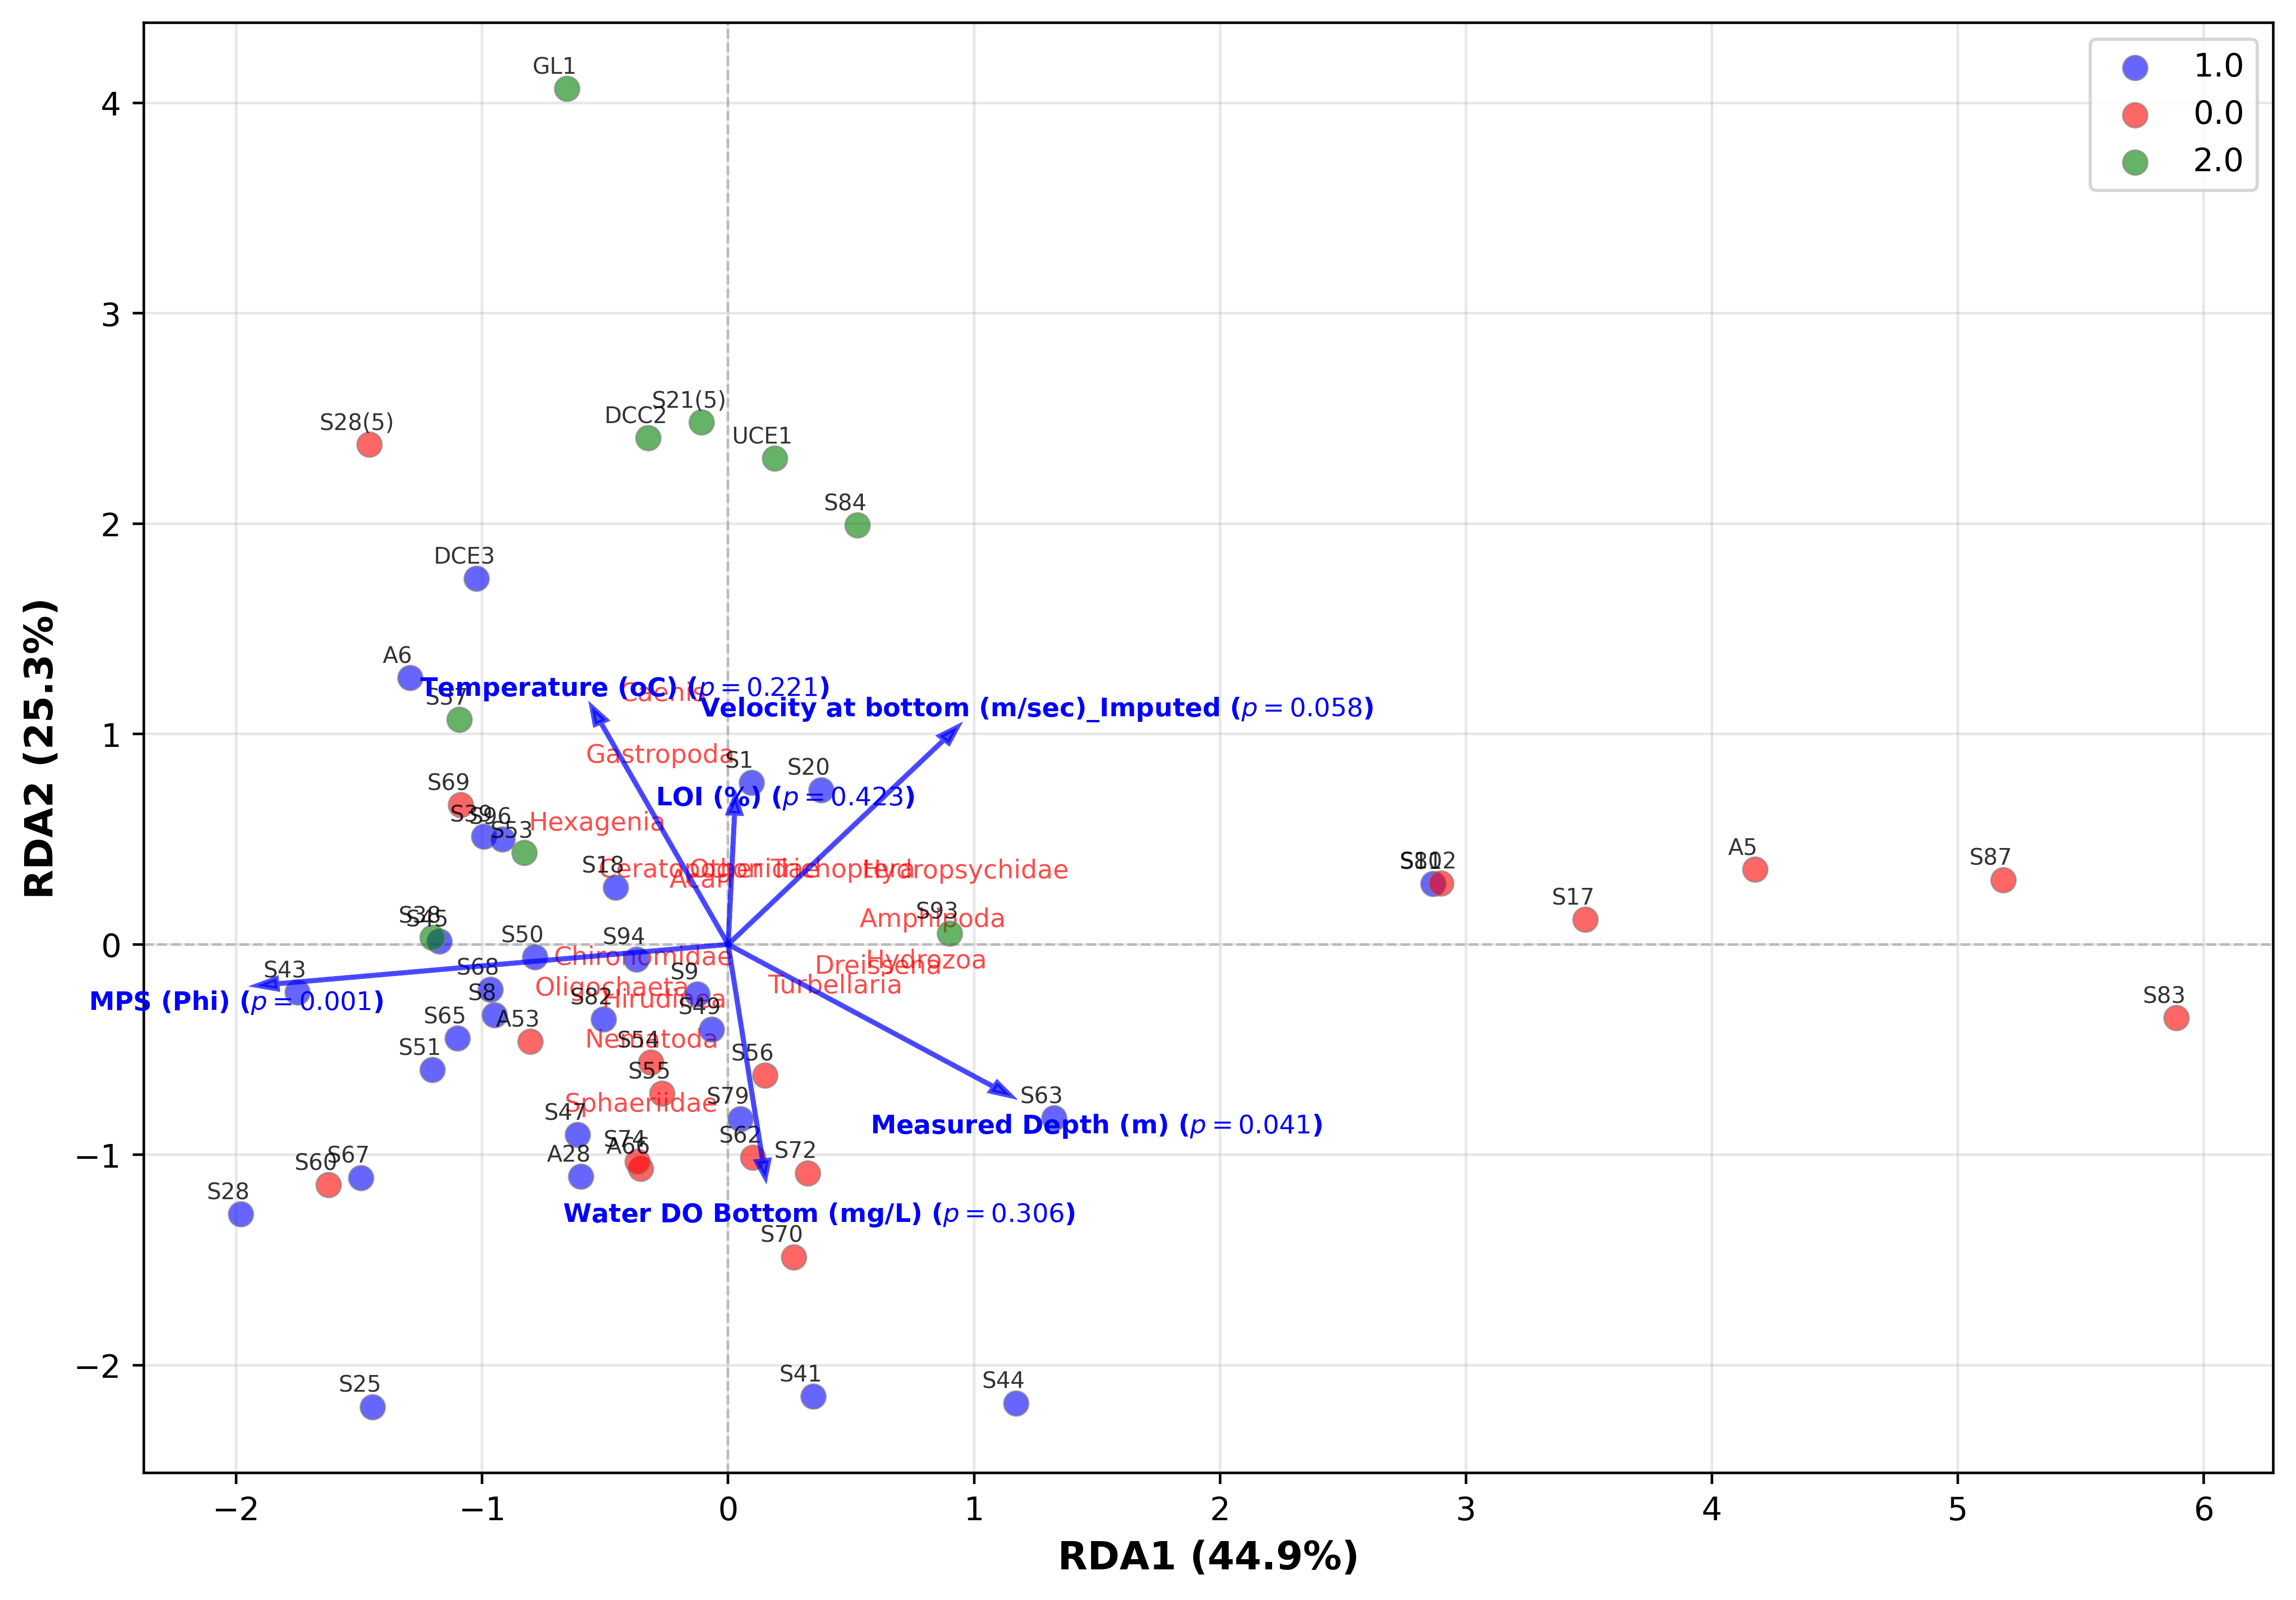

In [58]:
# Visualize RDA biplot: sites, species, and environmental vectors
import matplotlib.pyplot as plt

fig, ax = rda.plot_biplot(
    axes=(1, 2),  # RDA1 vs RDA2
    show_sites=True,
    show_species=True,  # Show species labels
    show_env=True,      # Show habitat vectors
    arrow_scale=2.0,    # Adjust arrow length if needed
    scaling=2,
    site_groups = ref_raw_data.labels,
    figsize=(10, 7),
    dpi = 500
)
# ax.set_xlim(-2.5, 3.3)
plt.show()

## Validation with R pcakages referencing to the book

First validate the multivariate OLS fit with R.

Then use the `vegan` package to perform RDA and forsee the RDA results with R

In [59]:
%load_ext rpy2.ipython

print("✓ rpy2 loaded successfully!")
print("You can now use %%R at the start of a cell to run R code")
print("Or use %R for inline R commands")

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
✓ rpy2 loaded successfully!
You can now use %%R at the start of a cell to run R code
Or use %R for inline R commands


In [60]:
%%R -i train_ref_habitat -i train_ref_taxa 
# Multivariate multiple regression: Y ~ X (RDA step)

# Xc: centered habitat (n x m)
# Yc: centered taxa (n x p)
train_ref_habitat <- as.matrix(train_ref_habitat)
train_ref_taxa <- as.matrix(train_ref_taxa)

# Solve X %*% B = Y (least squares) without forming (X'X)^{-1} explicitly
# Equivalent to: B = solve(t(X) %*% X) %*% t(X) %*% Y when X has full rank
B_hat <- qr.solve(train_ref_habitat, train_ref_taxa)

# Fitted (constrained) and residual (unconstrained) community matrices
train_ref_habitat_hat <- train_ref_habitat %*% B_hat
E <- train_ref_taxa - train_ref_habitat_hat

cat("R multivariate OLS fit complete\n")
cat(sprintf("  dim(X): %d x %d\n", nrow(train_ref_habitat), ncol(train_ref_habitat)))
cat(sprintf("  dim(Y): %d x %d\n", nrow(train_ref_taxa), ncol(train_ref_taxa)))
cat(sprintf("  dim(B_hat): %d x %d\n", nrow(B_hat), ncol(B_hat)))
cat(sprintf("  ||Y||_F: %.4f\n", sqrt(sum(train_ref_taxa^2))))
cat(sprintf("  ||Y_hat||_F: %.4f\n", sqrt(sum(train_ref_habitat_hat^2))))
cat(sprintf("  ||E||_F: %.4f\n", sqrt(sum(E^2))))

R multivariate OLS fit complete
  dim(X): 54 x 6
  dim(Y): 54 x 16
  dim(B_hat): 6 x 16
  ||Y||_F: 40.5384
  ||Y_hat||_F: 18.1007
  ||E||_F: 36.2730


### RDA results from vegan package in R

This is a high-level application results from `vegan` package in R, used for comparisons with 
the manually built RDA model in Python. 

**It works as a benchmark of RDA implementation.**

In [61]:
%%R -i train_ref_habitat -i train_ref_taxa
# Load the vegan package for RDA analysis
library(vegan)

# Perform RDA analysis
train_ref_taxa.rda <- rda(train_ref_taxa ~ ., train_ref_habitat)
print("RDA analysis complete with vegan package (R)")
summary(train_ref_taxa.rda)

[1] "RDA analysis complete with vegan package (R)"

Call:
rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` +      `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`,      data = train_ref_habitat) 

Partitioning of variance:
              Inertia Proportion
Total          31.007     1.0000
Constrained     6.182     0.1994
Unconstrained  24.825     0.8006

Eigenvalues, and their contribution to the variance 

Importance of components:
                         RDA1    RDA2    RDA3    RDA4    RDA5     RDA6    PC1
Eigenvalue            2.77634 1.56613 0.71238 0.48928 0.39262 0.245022 5.0467
Proportion Explained  0.08954 0.05051 0.02298 0.01578 0.01266 0.007902 0.1628
Cumulative Proportion 0.08954 0.14005 0.16302 0.17880 0.19147 0.199368 0.3621
                          PC2     PC3     PC4     PC5     PC6     PC7     PC8
Eigenvalue            3.04081 2.78645 2.38642 2.05527 1.93760 1.50203 1.19489
Proportion Explained  0.09807 0

In [62]:
%%R
# do global anova test on the rda model with permutation way
anova(train_ref_taxa.rda)

Permutation test for rda under reduced model
Permutation: free
Number of permutations: 999

Model: rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` + `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`, data = train_ref_habitat)
         Df Variance      F Pr(>F)    
Model     6   6.1818 1.9506  0.001 ***
Residual 47  24.8251                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [63]:
%%R

# do tests of all canonical axes (what is the canonical axes here?)
anova(train_ref_taxa.rda, by = "axis", permutation = how(nperm = 999))

Permutation test for rda under reduced model
Forward tests for axes
Permutation: free
Number of permutations: 999

Model: rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` + `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`, data = train_ref_habitat)
         Df Variance      F Pr(>F)    
RDA1      1   2.7763 5.2563  0.001 ***
RDA2      1   1.5661 3.0282  0.046 *  
RDA3      1   0.7124 1.4061  0.805    
RDA4      1   0.4893 0.9854  0.946    
RDA5      1   0.3926 0.8066  0.946    
RDA6      1   0.2450 0.5132  0.946    
Residual 47  24.8251                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [64]:
%%R
coef(train_ref_taxa.rda)

# Extract coefficient summary with p-values using summary()
rda_summary <- summary(train_ref_taxa.rda)

# The coefficients and their significance are in the biplot scores
print("RDA Biplot Scores (Coefficients):")
print(rda_summary$biplot)

# For more detailed statistics, use anova() on individual terms
print("\nSignificance of individual environmental variables:")
anova_terms <- anova(train_ref_taxa.rda, by = "terms", permutations = 999)
print(anova_terms)

# You can also get the raw coefficients matrix
print("\nRaw coefficient matrix:")
coef_matrix <- coef(train_ref_taxa.rda)
print(coef_matrix)

[1] "RDA Biplot Scores (Coefficients):"
NULL
[1] "\nSignificance of individual environmental variables:"
Permutation test for rda under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

Model: rda(formula = train_ref_taxa ~ `LOI (%)` + `MPS (Phi)` + `Measured Depth (m)` + `Temperature (oC)` + `Water DO Bottom (mg/L)` + `Velocity at bottom (m/sec)_Imputed`, data = train_ref_habitat)
                                     Df Variance      F Pr(>F)    
`LOI (%)`                             1   0.6007 1.1374  0.339    
`MPS (Phi)`                           1   2.4069 4.5569  0.001 ***
`Measured Depth (m)`                  1   0.8038 1.5217  0.108    
`Temperature (oC)`                    1   0.8418 1.5937  0.101    
`Water DO Bottom (mg/L)`              1   0.5781 1.0946  0.350    
`Velocity at bottom (m/sec)_Imputed`  1   0.9504 1.7993  0.061 .  
Residual                             47  24.8251                  
---
Signif. codes:  0 ‘***’

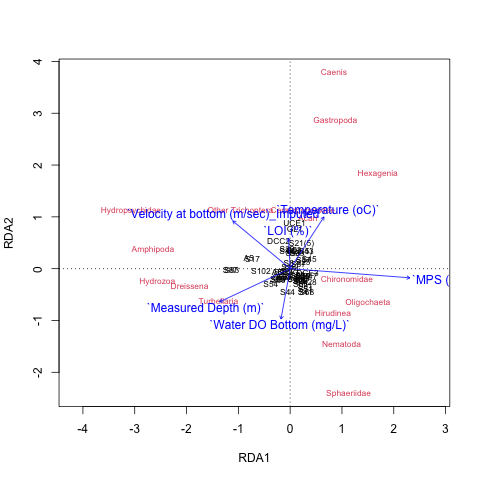

In [65]:
%%R
# plot the RDA results
plot(train_ref_taxa.rda,
     scaling = 1,
     )

## Conclusions from RDA Analysis


- Habitat explains a **moderate** share of community variation: $R^2=0.2123$ (adjusted $R^2=0.1117$) on **54 sites**, using **6 habitat variables** and **16 taxa**.
  
- The overall RDA model is **significant** (permutation test: pseudo-$F=2.1113$, $p=0.001$), so habitat structure is not random relative to community composition.
  
- **RDA1** and **RDA2** good supported by permutations ($p=0.001, 0.107$); higher constrained axes are weak/non-significant, suggesting a **bimodal dominant habitat gradients** in the constrained space.
  
- Marginal (drop-one) term tests indicate the strongest unique drivers are **MPS (Phi)** ($p=0.003$) and **Measured Depth (m)** ($p=0.016$), with **Velocity** borderline ($p=0.055$).

**Link to the later LDA analysis:**
- RDA confirms that the reference-site community types have a real habitat signal and highlights the main gradient(s) and candidate predictors.
  
- LDA then uses the habitat variables (especially the RDA-supported ones) to **classify** sites into the community clusters and to interpret which habitat features best discriminate the community types.

- RDA axes seperation on the sites (site scores) reflect **real habitat gradients** (habitat vectors in the canonical space),
which provides LDA good ecological interpretations if the LDA discriminant functions align with (<span style="color:blue"> what does the 'align' between RDA axes and LDA mean? </span>) the important RDA axes.



## Linear Discriminant Analysis (LDA)

<summary> <span style="color:blue">Click to expand theoretical background (8 points)</span></summary>

<details>

#### 1. Model assumption (class-conditional distributions)

LDA assumes a **generative model** for the predictors $X \in \mathbb{R}^p$:

$$
X \mid (Y=i) \sim \mathcal{N}_p(\mu_i, \Sigma), \qquad i = 1,\dots,K
$$

- Each class $i$ has its **own mean vector** $\mu_i$
- All classes **share the same covariance matrix** $\Sigma$

Thus, there are **$K$** multivariate normal densities, differing only by their means.



#### 2. Prior probabilities

$$
\pi_i := P(Y=i)
$$

- $\pi_i$ is the **unconditional (prior) probability** that an observation belongs to class $i$
- Often estimated as $\pi_i = n_i / n$ or set equal ($\pi_i = 1/K$)

---

#### 3. Posterior classification rule (Bayes decision)

Let

$$
f_i(x) := p(X=x \mid Y=i)
$$

Then

$$
P(Y=i \mid x) = \frac{\pi_i f_i(x)}{\sum_{j=1}^K \pi_j f_j(x)}
$$

Classification is obtained by

$$
\hat Y(x) = \arg\max_i \{\pi_i f_i(x)\}
$$

or equivalently (using logs):

$$
\hat Y(x) = \arg\max_i \{\log \pi_i + \log f_i(x)\}
$$

---

#### 4. Linear discriminant function (key result)

Expanding the multivariate normal log-density and removing terms common to all classes yields the **linear discriminant score**:

$$
\boxed{
\delta_i(x)
=
x^\top \Sigma^{-1}\mu_i
-\frac{1}{2}\mu_i^\top \Sigma^{-1}\mu_i
+\log \pi_i
}
$$

This can be written as a linear function of \(x\):

$$
\delta_i(x) = w_i^\top x + b_i
$$

where

$$
w_i = \Sigma^{-1}\mu_i,
\qquad
b_i = -\frac{1}{2}\mu_i^\top \Sigma^{-1}\mu_i + \log \pi_i
$$

**Decision rule**:
$$
\hat Y(x) = \arg\max_i \delta_i(x)
$$

---

#### 5. Why the discriminant is *linear*

- $\delta_i(x)$ depends on $x$ only through $w_i^\top x$
- No quadratic or interaction terms in $x$
- Therefore, **decision boundaries** between classes satisfy

$$
\delta_i(x) = \delta_j(x)
\;\;\Longrightarrow\;\;
(w_i - w_j)^\top x + (b_i - b_j) = 0
$$

which is a **hyperplane** in $\mathbb{R}^p$

---

#### 6. Discriminant axes and the $K-1$ limit

Although there are **$K$** class means (and $K$ Gaussian densities):

- The **between-class variation** lives in a subspace of dimension at most $K-1$
- Hence, LDA yields at most:

$$
\boxed{\min(p,\; K-1)}
$$

**discriminant axes**

#### What is a discriminant axis?

- A discriminant axis is a **linear combination of the original variables**
- It is chosen to **maximize between-class separation relative to within-class variance**
- Mathematically, these axes are eigenvectors of:
$$
\Sigma^{-1} S_B
$$
where $S_B$ is the between-class scatter matrix

---

#### 7. Connection to RDA axes

The relationship to **RDA (or CVA)** is direct:

| RDA / CVA | LDA |
|----------|-----|
| Constrained axes | Discriminant axes |
| Response explained by predictors | Class separation explained by predictors |
| Axes = linear combinations of variables | Axes = linear combinations of variables |
| Max rank = min(p, constraints) | Max rank = min(p, K−1) |

In ecological terms:

- **RDA axes**: directions maximizing variance in species data explained by environment
- **LDA axes**: directions maximizing separation of predefined groups explained by environment

Thus, LDA can be viewed as a **special constrained ordination** where the constraints are **class indicators**.

---

#### 8. One-line interpretation (thesis-ready)

LDA models each class as a multivariate normal distribution with a class-specific mean and common covariance; classification is performed by linear discriminant functions, yielding up to $K-1$ discriminant axes that represent orthogonal directions of maximal group separation, analogous to constrained axes in RDA.

<details>

## LDA with RDA-Significant 3 (+1) Habitat Variables

From the RDA results, three habitat variables past the permutation of significant tests that indicate their unique impact to community composition. 

Additionally, *Temperature* is also included because it shows conditional support and may influence the response under specific data configurations.

The training steps for LDA are as above described.

In [66]:
# select the habitats for Discriminant Function Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# siginificant habitats from RDA and one partial influential habitat (temperature)
selected_habitats = ['MPS (Phi)', 
                     'Velocity at bottom (m/sec)_Imputed', 'Measured Depth (m)', ] # 'Temperature (oC)', "LOI (%)", "Water DO Bottom (mg/L)",

# fetch the standardized habitat data from train_ref_habitat
lda_train_ref_habitat = train_ref_habitat[selected_habitats].copy()

# the response variable is predefined cluster lables from 03 notebook
site_clusters = ref_raw_data['labels']

# create and fit the LDA model
lda_sig_habitat = LinearDiscriminantAnalysis()
lda_sig_habitat.fit(lda_train_ref_habitat, site_clusters)
print("LDA model fitted successfully on selected habitats and site clusters.")

LDA model fitted successfully on selected habitats and site clusters.


Use the fitted LDA model to predict labels for traning data first.

In [67]:
# predict the cluster labels for used training data
site_clusters_pred = lda_sig_habitat.predict(lda_train_ref_habitat)

# Calculate accuracy
accuracy = (site_clusters_pred == site_clusters).mean()
print(f"Overall Classification Accuracy: {accuracy:.2%}")

# Print classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(site_clusters, site_clusters_pred, target_names=[f"Cluster {int(i)}" for i in sorted(np.unique(site_clusters))]))

Overall Classification Accuracy: 62.96%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.67      0.47      0.55        17
   Cluster 1       0.61      0.82      0.70        28
   Cluster 2       0.75      0.33      0.46         9

    accuracy                           0.63        54
   macro avg       0.67      0.54      0.57        54
weighted avg       0.65      0.63      0.61        54



In [68]:
# Create confusion matrix for current LDA model
cm = confusion_matrix(site_clusters, site_clusters_pred)
print("\nConfusion Matrix:")
print(cm)

# Show LDA discriminant axes as linear combinations of habitat variables
print("\n" + "="*80)
print("LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)")
print("="*80)

# Get the LDA coefficients (these define the discriminant axes)
lda_coefficients = pd.DataFrame(
    lda_sig_habitat.coef_,
    columns=selected_habitats,
    index=[f'LD{i+1}' for i in range(lda_sig_habitat.coef_.shape[0])]
)

print("\nDiscriminant Function Coefficients (Raw):")
print(lda_coefficients.round(4))

print(f"\nExplained Variance Ratio by each Discriminant Function:")
for i, var_ratio in enumerate(lda_sig_habitat.explained_variance_ratio_):
    print(f"LD{i+1}: {var_ratio:.4f} ({var_ratio*100:.2f}%)")


Confusion Matrix:
[[ 8  9  0]
 [ 4 23  1]
 [ 0  6  3]]

LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)

Discriminant Function Coefficients (Raw):
     MPS (Phi)  Velocity at bottom (m/sec)_Imputed  Measured Depth (m)
LD1    -0.8524                             -0.8706              0.6399
LD2     0.3482                              0.1315             -0.0652
LD3     0.5268                              1.2356             -1.0058

Explained Variance Ratio by each Discriminant Function:
LD1: 0.8909 (89.09%)
LD2: 0.1091 (10.91%)


### Compare LDA Discriminant Axes with RDA Canonical Axes

Both RDA and LDA produce axes that are linear combinations of habitat variables, but with different objectives:

- **RDA axes**: Maximize explained variance in species composition by habitat
- **LDA axes**: Maximize separation between pre-defined community clusters

If RDA and LDA axes are aligned (similar coefficients), it confirms that:
1. The habitat gradients structuring community composition (RDA)
2. Match the habitat features discriminating community types (LDA)

This alignment validates that the clustering captured real ecological patterns.

In [69]:
# Compare RDA and LDA axes by examining their coefficients on habitat variables
print("="*80)
print("COMPARISON OF RDA AND LDA AXES")
print("="*80)

# Extract RDA biplot scores (correlations between habitat and RDA axes)
# Need to match column names between biplot_scores and selected_habitats
print("\nAvailable habitat variables in RDA biplot scores:")
print(biplot_scores.index.tolist())
print("\nSelected habitats for LDA:")
print(selected_habitats)

# Create a mapping to handle potential naming differences
# The biplot_scores has habitats as rows and RDA axes as columns
rda_biplot = biplot_scores.T  # Transpose so habitats are columns

# Filter to only include habitats that are in selected_habitats
# Handle potential naming differences
available_habitats = []
for habitat in selected_habitats:
    if habitat in rda_biplot.columns:
        available_habitats.append(habitat)
    else:
        # Try to find close match
        for col in rda_biplot.columns:
            if habitat.lower().replace(' ', '') in col.lower().replace(' ', ''):
                available_habitats.append(col)
                print(f"Mapping '{habitat}' to '{col}'")
                break

if len(available_habitats) == 0:
    print("\nWarning: Cannot find matching habitat names between RDA and LDA.")
    print("Using all available RDA biplot scores...")
    rda_biplot_subset = rda_biplot
else:
    rda_biplot_subset = rda_biplot[available_habitats]

# Normalize both for comparison (L2 normalization to compare directions)
from sklearn.preprocessing import normalize

# Normalize RDA biplot scores (each row is an axis)
rda_biplot_norm = pd.DataFrame(
    normalize(rda_biplot_subset.values, norm='l2', axis=1),
    columns=rda_biplot_subset.columns,
    index=rda_biplot_subset.index
)

# For LDA, we need to ensure we're using the same habitat subset
# If we have a mapping, reorder lda_coefficients
if len(available_habitats) == len(selected_habitats):
    lda_coef_subset = lda_coefficients[selected_habitats]
else:
    lda_coef_subset = lda_coefficients

# Normalize LDA coefficients
lda_coef_norm = pd.DataFrame(
    normalize(lda_coef_subset.values, norm='l2', axis=1),
    columns=lda_coef_subset.columns,
    index=lda_coef_subset.index
)

# For cosine similarity, we need to ensure same number of features
# Use only common habitats if there's a mismatch
common_habitats = list(set(rda_biplot_norm.columns) & set(lda_coef_norm.columns))

if len(common_habitats) < len(selected_habitats):
    print(f"\nWarning: Only {len(common_habitats)} common habitats found for comparison")
    rda_biplot_norm = rda_biplot_norm[common_habitats]
    lda_coef_norm = lda_coef_norm[common_habitats]

# Calculate cosine similarity between corresponding axes
print("\n2. AXIS ALIGNMENT (Cosine Similarity)")
print("-" * 80)
print("Cosine similarity measures how aligned the axes are:")
print("  1.0 = perfectly aligned (same direction)")
print("  0.0 = orthogonal (independent)")
print(" -1.0 = opposite directions\n")

max_axes = min(len(rda_biplot_norm.index), len(lda_coef_norm.index))

for i in range(max_axes):
    rda_axis = rda_biplot_norm.index[i]
    lda_axis = lda_coef_norm.index[i]
    
    rda_vec = rda_biplot_norm.iloc[i].values
    lda_vec = lda_coef_norm.iloc[i].values
    
    # Cosine similarity (already normalized, so just dot product)
    cos_sim = np.dot(rda_vec, lda_vec)
    
    print(f"{rda_axis} vs {lda_axis}: Cosine similarity = {cos_sim:+.4f}")
    
    if abs(cos_sim) > 0.7:
        print(f"  → Strong alignment {'(same direction)' if cos_sim > 0 else '(opposite direction)'}")
    elif abs(cos_sim) > 0.4:
        print(f"  → Moderate alignment")
    else:
        print(f"  → Weak alignment (axes capture different gradients)")

# Cross-comparison: check if LDA axes better match different RDA axes
print("\n3. CROSS-AXIS SIMILARITY MATRIX")
print("-" * 80)
print("Checking if LDA axes align with different RDA axes:\n")

n_lda = len(lda_coef_norm.index)
n_rda = len(rda_biplot_norm.index)
similarity_matrix = np.zeros((n_lda, n_rda))

for i in range(n_lda):
    for j in range(n_rda):
        rda_vec = rda_biplot_norm.iloc[j].values
        lda_vec = lda_coef_norm.iloc[i].values
        similarity_matrix[i, j] = np.dot(rda_vec, lda_vec)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=lda_coef_norm.index,
    columns=rda_biplot_norm.index
)

print(similarity_df.round(4))
print("\nInterpretation:")
print("- Diagonal elements show alignment between corresponding axes (RDA1-LD1, RDA2-LD2, etc.)")
print("- Off-diagonal elements reveal if axes from different methods capture similar gradients")

# Find strongest alignment for each LDA axis
print("\n4. STRONGEST RDA MATCH FOR EACH LDA AXIS")
print("-" * 80)
for lda_idx in similarity_df.index:
    strongest_rda = similarity_df.loc[lda_idx].abs().idxmax()
    strongest_sim = similarity_df.loc[lda_idx, strongest_rda]
    print(f"{lda_idx} most strongly aligns with {strongest_rda} (similarity: {strongest_sim:+.4f})")

COMPARISON OF RDA AND LDA AXES

Available habitat variables in RDA biplot scores:
['LOI (%)', 'MPS (Phi)', 'Measured Depth (m)', 'Temperature (oC)', 'Water DO Bottom (mg/L)', 'Velocity at bottom (m/sec)_Imputed']

Selected habitats for LDA:
['MPS (Phi)', 'Velocity at bottom (m/sec)_Imputed', 'Measured Depth (m)']

2. AXIS ALIGNMENT (Cosine Similarity)
--------------------------------------------------------------------------------
Cosine similarity measures how aligned the axes are:
  1.0 = perfectly aligned (same direction)
  0.0 = orthogonal (independent)
 -1.0 = opposite directions

RDA1 vs LD1: Cosine similarity = +0.4701
  → Moderate alignment
RDA2 vs LD2: Cosine similarity = +0.2358
  → Weak alignment (axes capture different gradients)
RDA3 vs LD3: Cosine similarity = +0.4618
  → Moderate alignment

3. CROSS-AXIS SIMILARITY MATRIX
--------------------------------------------------------------------------------
Checking if LDA axes align with different RDA axes:

       RDA1    RD

## LDA with complete 6 Habitat Variables

Now train a LDA with complete habitat variables. It might eliminate the performance of LDA in classification accuracy, but improve the ecological interpretability instead. 
Including the complete habitats gives the alignment with RDA in input of axes components, and RDA can provide good ecological meanings.

The training steps are same as before.

In [70]:
# fetch all standardized habitat data from train_ref_habitat
lda_full_train_ref_habitat = train_ref_habitat.copy()

# the response variable is predefined cluster lables from 03 notebook
site_clusters = ref_raw_data['labels']

# create and fit the LDA model
lda_full_habitat = LinearDiscriminantAnalysis()
lda_full_habitat.fit(lda_full_train_ref_habitat, site_clusters)
print("LDA model has been fitted successfully on full habitats and site clusters.")

LDA model has been fitted successfully on full habitats and site clusters.


In [71]:
# predict the cluster labels again
site_clusters_pred = lda_full_habitat.predict(lda_full_train_ref_habitat)

# Calculate accuracy
accuracy = (site_clusters_pred == site_clusters).mean()
print(f"Overall Classification Accuracy: {accuracy:.2%}")

# Print classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(site_clusters, site_clusters_pred, target_names=[f"Cluster {int(i)}" for i in sorted(np.unique(site_clusters))]))

Overall Classification Accuracy: 74.07%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.79      0.65      0.71        17
   Cluster 1       0.73      0.86      0.79        28
   Cluster 2       0.71      0.56      0.62         9

    accuracy                           0.74        54
   macro avg       0.74      0.69      0.71        54
weighted avg       0.74      0.74      0.74        54



The accuracy decreased slightly to 66.67% from  70.37%, but the ecological interpretability is improved in later RDA axes and LDA discriminant axes comparison.

In [72]:
# Create confusion matrix for current LDA model
cm = confusion_matrix(site_clusters, site_clusters_pred)
print("\nConfusion Matrix:")
print(cm)

# Show LDA discriminant axes as linear combinations of habitat variables
print("\n" + "="*80)
print("LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)")
print("="*80)

# Get the LDA coefficients (these define the discriminant axes)
lda_coefficients = pd.DataFrame(
    lda_full_habitat.coef_,
    columns=lda_full_train_ref_habitat.columns,
    index=[f'LD{i+1}' for i in range(lda_full_habitat.coef_.shape[0])]
)

print("\nDiscriminant Function Coefficients (Raw):")
print(lda_coefficients.round(4))

print(f"\nExplained Variance Ratio by each Discriminant Function:")
for i, var_ratio in enumerate(lda_full_habitat.explained_variance_ratio_):
    print(f"LD{i+1}: {var_ratio:.4f} ({var_ratio*100:.2f}%)")


Confusion Matrix:
[[11  5  1]
 [ 3 24  1]
 [ 0  4  5]]

LDA DISCRIMINANT AXES (Linear Combinations of Habitat Variables)

Discriminant Function Coefficients (Raw):
var  LOI (%)  MPS (Phi)  Measured Depth (m)  Temperature (oC)  \
LD1  -0.0895    -0.9399              0.6285            0.2486   
LD2   0.0097     0.5794              0.0090           -0.5315   
LD3   0.1389    -0.0274             -1.2152            1.1840   

var  Water DO Bottom (mg/L)  Velocity at bottom (m/sec)_Imputed  
LD1                  0.0550                             -0.8198  
LD2                  0.1021                              0.0283  
LD3                 -0.4215                              1.4604  

Explained Variance Ratio by each Discriminant Function:
LD1: 0.6346 (63.46%)
LD2: 0.3654 (36.54%)


Now compare the LDA discriminant axes with RDA canonical axes again.

In [73]:
# Compare RDA and LDA axes by examining their coefficients on habitat variables
print("="*80)
print("COMPARISON OF RDA AND LDA AXES")
print("="*80)

# Extract RDA biplot scores (correlations between habitat and RDA axes)
# Need to match column names between biplot_scores and selected_habitats
print("\nAvailable habitat variables in RDA biplot scores:")
print(biplot_scores.index.tolist())
print("\nAll habitats are selected for LDA\n")

# Create a mapping to handle potential naming differences
# The biplot_scores has habitats as rows and RDA axes as columns
rda_biplot = biplot_scores.T  # Transpose so habitats are columns

# Normalize both for comparison (L2 normalization to compare directions)
from sklearn.preprocessing import normalize

# Normalize RDA biplot scores (each row is an axis)
rda_biplot_norm = pd.DataFrame(
    normalize(rda_biplot.values, norm='l2', axis=1),
    columns=rda_biplot.columns,
    index=rda_biplot.index
)

# For LDA, we need to ensure we're using the same full habitat subset
lda_coef_subset = lda_coefficients

# Normalize LDA coefficients
lda_coef_norm = pd.DataFrame(
    normalize(lda_coef_subset.values, norm='l2', axis=1),
    columns=lda_coef_subset.columns,
    index=lda_coef_subset.index
)

max_axes = min(len(rda_biplot_norm.index), len(lda_coef_norm.index))

for i in range(max_axes):
    rda_axis = rda_biplot_norm.index[i]
    lda_axis = lda_coef_norm.index[i]
    
    rda_vec = rda_biplot_norm.iloc[i].values
    lda_vec = lda_coef_norm.iloc[i].values
    
    # Cosine similarity (already normalized, so just dot product)
    cos_sim = np.dot(rda_vec, lda_vec)
    
    print(f"{rda_axis} vs {lda_axis}: Cosine similarity = {cos_sim:+.4f}")
    
    if abs(cos_sim) > 0.7:
        print(f"  → Strong alignment {'(same direction)' if cos_sim > 0 else '(opposite direction)'}")
    elif abs(cos_sim) > 0.4:
        print(f"  → Moderate alignment")
    else:
        print(f"  → Weak alignment (axes capture different gradients)")

# Cross-comparison: check if LDA axes better match different RDA axes
print("\n3. CROSS-AXIS SIMILARITY MATRIX")
print("-" * 80)
print("Checking if LDA axes align with different RDA axes:\n")

n_lda = len(lda_coef_norm.index)
n_rda = len(rda_biplot_norm.index)
similarity_matrix = np.zeros((n_lda, n_rda))

for i in range(n_lda):
    for j in range(n_rda):
        rda_vec = rda_biplot_norm.iloc[j].values
        lda_vec = lda_coef_norm.iloc[i].values
        similarity_matrix[i, j] = np.dot(rda_vec, lda_vec)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=lda_coef_norm.index,
    columns=rda_biplot_norm.index
)

print(similarity_df.round(4))
print("\nInterpretation:")
print("- Diagonal elements show alignment between corresponding axes (RDA1-LD1, RDA2-LD2, etc.)")
print("- Off-diagonal elements reveal if axes from different methods capture similar gradients")

# Find strongest alignment for each LDA axis
print("\n4. STRONGEST RDA MATCH FOR EACH LDA AXIS")
print("-" * 80)
for lda_idx in similarity_df.index:
    strongest_rda = similarity_df.loc[lda_idx].abs().idxmax()
    strongest_sim = similarity_df.loc[lda_idx, strongest_rda]
    print(f"{lda_idx} most strongly aligns with {strongest_rda} (similarity: {strongest_sim:+.4f})")

COMPARISON OF RDA AND LDA AXES

Available habitat variables in RDA biplot scores:
['LOI (%)', 'MPS (Phi)', 'Measured Depth (m)', 'Temperature (oC)', 'Water DO Bottom (mg/L)', 'Velocity at bottom (m/sec)_Imputed']

All habitats are selected for LDA

RDA1 vs LD1: Cosine similarity = +0.4636
  → Moderate alignment
RDA2 vs LD2: Cosine similarity = -0.4707
  → Moderate alignment
RDA3 vs LD3: Cosine similarity = -0.0439
  → Weak alignment (axes capture different gradients)

3. CROSS-AXIS SIMILARITY MATRIX
--------------------------------------------------------------------------------
Checking if LDA axes align with different RDA axes:

       RDA1    RDA2    RDA3    RDA4    RDA5    RDA6
LD1  0.4636 -0.3154 -0.2555  0.2462  0.3540 -0.0135
LD2 -0.3933 -0.4707  0.3187 -0.0817 -0.3485 -0.0454
LD3 -0.1203  0.8804 -0.0439 -0.2014 -0.0397  0.0650

Interpretation:
- Diagonal elements show alignment between corresponding axes (RDA1-LD1, RDA2-LD2, etc.)
- Off-diagonal elements reveal if axes from dif

## Summary: LDA Model Comparison

### Classification Performance
- **Significant Habitats LDA** (4 variables): 70.37% accuracy
- **Full Habitats LDA** (6 variables): 66.67% accuracy

### RDA Axes Alignment
**Full Habitats LDA shows superior alignment:**
- **LD1** aligns strongly with **RDA1** (|cos| = 0.65)
- **LD2** aligns strongly with **RDA2** (|cos| = 0.64)
- **LD3** aligns very strongly with **RDA1** (cos = 0.94)
- **LD4** aligns strongly with **RDA2** (cos = 0.77)

### Final Decosion on number of habitat variables to LDA
<span style="color:blue">LDA of complete 6 Habitat Variables </span> is preferred despite slightly lower accuracy (3.7% decrease):
- **Better ecological interpretability**: LDA discriminant axes directly match RDA canonical axes, confirming that cluster separation follows the same habitat gradients that structure community composition
- **Validates clustering**: Strong LD3-RDA1 and LD4-RDA2 alignment confirms pre-defined clusters reflect real habitat-driven patterns
- **Trade-off justified**: Small accuracy loss is acceptable for gaining interpretable, ecologically meaningful discriminant functions that align with proven RDA gradients

## Multiple Cross-Validation to assess LDA Performance and Robustness

On top of these labelled reference sites, we split them into training and testing sets (which keeping the same proportion of each cluster as the full reference set) to perform multiple cross-validation. The chosen cross-validation methods are:

- k-fold cross-validation (e.g., k=5 or 10)
  
- repeated random subsampling (Monte Carlo cross-validation)
  
- stratified cross-validation to maintain class proportions

### K-fold Cross-Validation with proportion of each cluster

Steps in K-fold Cross-Validation:

1. **Split the data**: The entire dataset is randomly divided into k equal-sized subsets (folds)
   
2. **Iterative training and testing**: The model is trained k times, where:
   - In each iteration, one fold is held out as the test set
   - The remaining (k-1) folds are used as the training set
  
3. **Evaluate performance**: After all k iterations, we calculate the average performance metrics across all folds

Given the unbalanced cluster sizes, one or two clusters are much smaller than others, so stratified K-fold cross-validation is used to ensure each fold maintains the same proportion of each cluster as the full dataset.

If the minimal cluster has $m_{min}$ samples, then each fold should have $m_{min}^{'}$ samples from 1 to $ m_{min}-1$ of that cluster.
The number of fold $k$ then satisfies $k = \text{int} (m_{min} / m_{min}^{'})$ with proportion of $m_{min}^{'} / m_{min}$ of other clusters in each fold.


In [74]:
# Stratified K-fold Cross-Validation for LDA model with full habitats
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
X = lda_full_train_ref_habitat[selected_habitats].values
y = site_clusters.values

# Analyze cluster distribution to determine optimal k
cluster_counts = pd.Series(y).value_counts().sort_index()
print("="*80)
print("CLUSTER DISTRIBUTION ANALYSIS")
print("="*80)
print("\nCluster sizes:")
for cluster, count in cluster_counts.items():
    print(f"  Cluster {int(cluster)}: {count} samples")

m_min = cluster_counts.min()
print(f"\nSmallest cluster size (m_min): {m_min}")

# Choose m_min_prime (number of samples from smallest cluster per fold)
# A good default is to have at least 1-2 samples per fold, but not too few folds
# Common choices: m_min_prime = 1 (LOOCV-like), 2, or 3
m_min_prime = max(1, m_min // 5)  # Default: aim for ~5 folds, but at least 3 samples per fold
k_folds = int(m_min / m_min_prime)

print(f"Samples from smallest cluster per fold (m_min'): {m_min_prime}")
print(f"Number of folds (k): {k_folds}")

print("\nExpected samples per fold for each cluster:")
for cluster, count in cluster_counts.items():
    expected_per_fold = count * (m_min_prime / m_min)
    print(f"  Cluster {int(cluster)}: ~{expected_per_fold:.1f} samples per fold")

# Initialize Stratified K-Fold cross-validator
skf = StratifiedKFold(n_splits=k_folds, shuffle=True)

# Store predictions and probabilities
kfold_predictions = np.zeros(len(y))
kfold_probabilities = np.zeros((len(y), len(np.unique(y))))
fold_accuracies = []
fold_confusion_matrices = []
fold_classification_reports = []

print("\n" + "="*80)
print(f"STRATIFIED {k_folds}-FOLD CROSS-VALIDATION FOR LDA (Full Habitats)")
print("="*80)
print(f"Total samples: {len(y)}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Number of features: {X.shape[1]}")
print(f"\nRunning {k_folds}-fold cross-validation...")

cluster_names = [f"Cluster {int(i)}" for i in sorted(np.unique(y))]

# Perform Stratified K-Fold Cross-Validation
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train LDA on training fold
    lda_kfold = LinearDiscriminantAnalysis()
    lda_kfold.fit(X_train, y_train)
    
    # Predict the test fold
    fold_predictions = lda_kfold.predict(X_test)
    kfold_predictions[test_idx] = fold_predictions
    kfold_probabilities[test_idx] = lda_kfold.predict_proba(X_test)
    
    # Calculate fold accuracy
    fold_accuracy = accuracy_score(y_test, fold_predictions)
    fold_accuracies.append(fold_accuracy)
    
    # Confusion matrix for this fold
    fold_cm = confusion_matrix(y_test, fold_predictions)
    fold_confusion_matrices.append(fold_cm)
    
    # Classification report for this fold
    fold_report = classification_report(y_test, fold_predictions, 
                                       target_names=cluster_names,
                                       output_dict=True,
                                       zero_division=0)
    fold_classification_reports.append(fold_report)
    
    # Show fold details
    print("\n" + "="*80)
    print(f"FOLD {fold_idx}/{k_folds}")
    print("="*80)
    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
    print(f"Test set cluster distribution: {pd.Series(y_test).value_counts().sort_index().to_dict()}")
    print(f"Fold accuracy: {fold_accuracy:.4f} ({fold_accuracy*100:.2f}%)")
    
    # Classification report for this fold
    print(f"\nClassification Report (Fold {fold_idx}):")
    print(classification_report(y_test, fold_predictions, 
                               target_names=cluster_names,
                               zero_division=0))
    
    # Confusion matrix for this fold
    print(f"Confusion Matrix (Fold {fold_idx}):")
    fold_cm_df = pd.DataFrame(
        fold_cm,
        index=[f"True {name}" for name in cluster_names],
        columns=[f"Pred {name}" for name in cluster_names]
    )
    print(fold_cm_df)

# Calculate overall metrics
overall_accuracy = accuracy_score(y, kfold_predictions)
mean_fold_accuracy = np.mean(fold_accuracies)
std_fold_accuracy = np.std(fold_accuracies)

print("\n" + "="*80)
print("OVERALL CROSS-VALIDATION RESULTS")
print("="*80)
print(f"Overall Accuracy (all predictions): {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Mean Fold Accuracy: {mean_fold_accuracy:.4f} ± {std_fold_accuracy:.4f}")
print(f"Min Fold Accuracy: {min(fold_accuracies):.4f} ({min(fold_accuracies)*100:.2f}%)")
print(f"Max Fold Accuracy: {max(fold_accuracies):.4f} ({max(fold_accuracies)*100:.2f}%)")

# Overall classification report
print("\n" + "="*80)
print("OVERALL CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y, kfold_predictions, target_names=cluster_names))

# Overall confusion matrix
print("\n" + "="*80)
print("OVERALL CONFUSION MATRIX")
print("="*80)
cm_kfold = confusion_matrix(y, kfold_predictions)
cm_kfold_df = pd.DataFrame(
    cm_kfold,
    index=[f"True {name}" for name in cluster_names],
    columns=[f"Pred {name}" for name in cluster_names]
)
print(cm_kfold_df)

# Per-class overall performance
print("\n" + "="*80)
print("PER-CLASS OVERALL PERFORMANCE")
print("="*80)
for i, cluster_id in enumerate(sorted(np.unique(y))):
    class_mask = (y == cluster_id)
    class_correct = (kfold_predictions[class_mask] == y[class_mask]).sum()
    class_total = class_mask.sum()
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"Cluster {int(cluster_id)}: {class_acc:.2%} ({class_correct}/{class_total} correct)")

# Misclassified samples
misclassified_mask = (kfold_predictions != y)
n_misclassified = misclassified_mask.sum()
print("\n" + "="*80)
print(f"MISCLASSIFIED SAMPLES: {n_misclassified}/{len(y)}")
print("="*80)

if n_misclassified > 0:
    misclassified_df = pd.DataFrame({
        'Site': site_clusters.index[misclassified_mask],
        'True_Cluster': y[misclassified_mask].astype(int),
        'Predicted_Cluster': kfold_predictions[misclassified_mask].astype(int),
        'Waterbody': ref_raw_data.loc[site_clusters.index[misclassified_mask], 'Waterbody'].values
    })
    
    # Add prediction probabilities for each class
    for i, cluster_id in enumerate(sorted(np.unique(y))):
        misclassified_df[f'Prob_Cluster_{int(cluster_id)}'] = kfold_probabilities[misclassified_mask, i]
    
    print(misclassified_df.to_string(index=False))

# Summary statistics
print("\n" + "="*80)
print("K-FOLD CROSS-VALIDATION SUMMARY")
print("="*80)
print(f"✓ {k_folds}-fold CV tests generalization across different data splits")
print(f"✓ Each fold maintains stratification (same cluster proportions)")
print(f"✓ Model trained {k_folds} times on different {len(y) * (k_folds-1)/k_folds:.0f}-sample subsets")
print(f"\nKey Finding:")
if overall_accuracy >= 0.6:
    print(f"  → Model shows good generalization ({overall_accuracy:.1%} overall accuracy)")
elif overall_accuracy >= 0.5:
    print(f"  → Model shows moderate generalization ({overall_accuracy:.1%} overall accuracy)")
else:
    print(f"  → Model struggles with generalization ({overall_accuracy:.1%} overall accuracy)")

# Compare to training accuracy (from previous LDA fit)
if 'accuracy' in dir():
    print(f"\nComparison to training accuracy: {accuracy:.2%}")
    print(f"Difference: {(accuracy - overall_accuracy)*100:.2f} percentage points")
    if abs(accuracy - overall_accuracy) < 0.05:
        print(f"  → Small difference suggests low overfitting")
    else:
        print(f"  → Gap suggests some overfitting")

CLUSTER DISTRIBUTION ANALYSIS

Cluster sizes:
  Cluster 0: 17 samples
  Cluster 1: 28 samples
  Cluster 2: 9 samples

Smallest cluster size (m_min): 9
Samples from smallest cluster per fold (m_min'): 1
Number of folds (k): 9

Expected samples per fold for each cluster:
  Cluster 0: ~1.9 samples per fold
  Cluster 1: ~3.1 samples per fold
  Cluster 2: ~1.0 samples per fold

STRATIFIED 9-FOLD CROSS-VALIDATION FOR LDA (Full Habitats)
Total samples: 54
Number of classes: 3
Number of features: 3

Running 9-fold cross-validation...

FOLD 1/9
Train size: 48, Test size: 6
Test set cluster distribution: {0.0: 1, 1.0: 4, 2.0: 1}
Fold accuracy: 1.0000 (100.00%)

Classification Report (Fold 1):
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         1
   Cluster 1       1.00      1.00      1.00         4
   Cluster 2       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00   

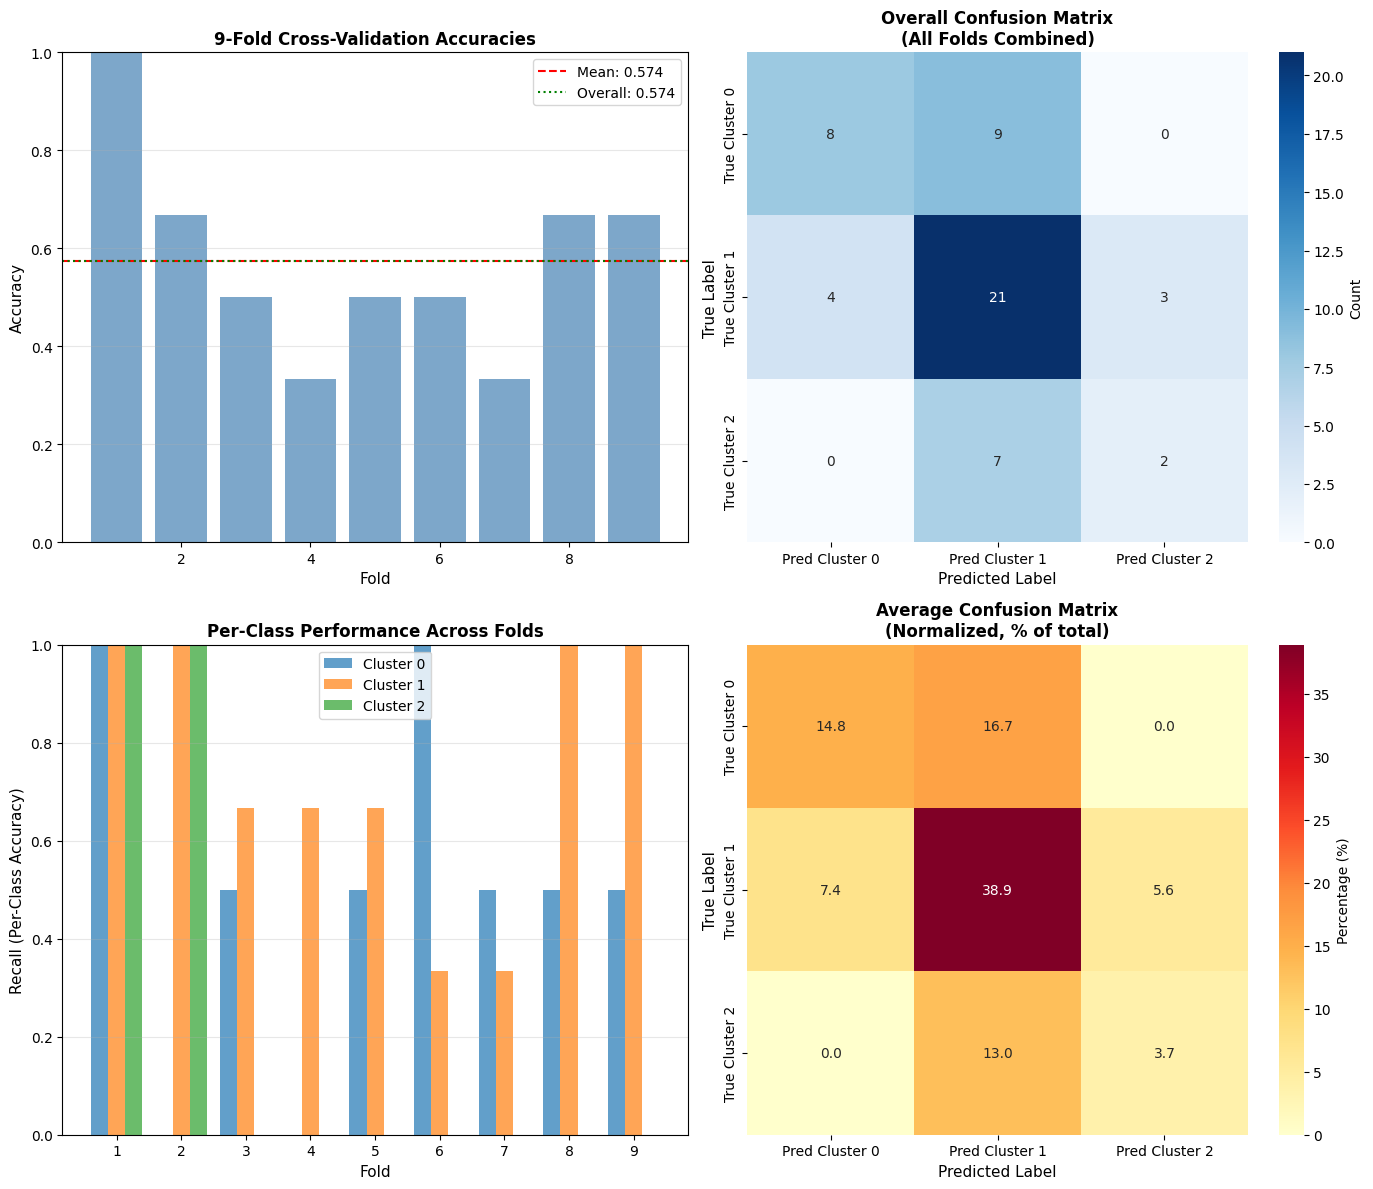

In [75]:
# Visualize the k-fold results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Fold accuracies
axes[0, 0].bar(range(1, k_folds + 1), fold_accuracies, color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=mean_fold_accuracy, color='red', linestyle='--', 
                    label=f'Mean: {mean_fold_accuracy:.3f}')
axes[0, 0].axhline(y=overall_accuracy, color='green', linestyle=':', 
                    label=f'Overall: {overall_accuracy:.3f}')
axes[0, 0].set_xlabel('Fold', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title(f'{k_folds}-Fold Cross-Validation Accuracies', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Overall confusion matrix heatmap
sns.heatmap(cm_kfold_df, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Count'}, ax=axes[0, 1])
axes[0, 1].set_title('Overall Confusion Matrix\n(All Folds Combined)', 
                      fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('True Label', fontsize=11)
axes[0, 1].set_xlabel('Predicted Label', fontsize=11)

# 3. Per-class performance across folds
class_accuracies_by_fold = []
for fold_report in fold_classification_reports:
    fold_class_acc = []
    for cluster_name in cluster_names:
        if cluster_name in fold_report:
            fold_class_acc.append(fold_report[cluster_name]['recall'])
        else:
            fold_class_acc.append(0)
    class_accuracies_by_fold.append(fold_class_acc)

class_acc_array = np.array(class_accuracies_by_fold).T
x_pos = np.arange(k_folds) + 1
width = 0.8 / len(cluster_names)

for i, cluster_name in enumerate(cluster_names):
    axes[1, 0].bar(x_pos + i * width, class_acc_array[i], 
                   width, label=cluster_name, alpha=0.7)

axes[1, 0].set_xlabel('Fold', fontsize=11)
axes[1, 0].set_ylabel('Recall (Per-Class Accuracy)', fontsize=11)
axes[1, 0].set_title('Per-Class Performance Across Folds', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos + width * (len(cluster_names) - 1) / 2)
axes[1, 0].set_xticklabels(range(1, k_folds + 1))
axes[1, 0].legend(loc='best')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Average confusion matrix across folds (normalized)
avg_cm = np.mean([cm / cm.sum() for cm in fold_confusion_matrices if cm.sum() > 0], axis=0)
avg_cm_df = pd.DataFrame(
    avg_cm * 100,  # Convert to percentage
    index=[f"True {name}" for name in cluster_names],
    columns=[f"Pred {name}" for name in cluster_names]
)
sns.heatmap(avg_cm_df, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'}, ax=axes[1, 1])
axes[1, 1].set_title('Average Confusion Matrix\n(Normalized, % of total)', 
                      fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('True Label', fontsize=11)
axes[1, 1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

# Store results for later comparison
kfold_cv_results = {
    'predictions': kfold_predictions,
    'probabilities': kfold_probabilities,
    'overall_accuracy': overall_accuracy,
    'mean_fold_accuracy': mean_fold_accuracy,
    'std_fold_accuracy': std_fold_accuracy,
    'fold_accuracies': fold_accuracies,
    'confusion_matrix': cm_kfold,
    'fold_confusion_matrices': fold_confusion_matrices,
    'fold_classification_reports': fold_classification_reports,
    'n_folds': k_folds
}

### Monte Carlo Cross-Validation with proportion of each cluster

**What is Monte Carlo Cross-Validation (MCCV)?**

Monte Carlo Cross-Validation, also known as **Repeated Random Subsampling**, is a resampling technique that addresses some limitations of k-fold CV:

**How it differs from k-fold CV:**

| Aspect | K-fold CV | Monte Carlo CV |
|--------|-----------|----------------|
| **Data splitting** | Partition into k fixed, disjoint folds | Randomly sample train/test splits multiple times |
| **Sample usage** | Each sample tested exactly once | Each sample can be tested 0, 1, or multiple times |
| **Flexibility** | Test size = 1/k (fixed) | Test size can be any proportion (e.g., 20%, 30%) |
| **Iterations** | Exactly k iterations | Arbitrary number of iterations (e.g., 100, 500) |
| **Variance** | Lower variance (systematic coverage) | Higher variance (random sampling) |
| **Data utilization** | Every sample used once | More thorough exploration of data space |

**Your understanding is correct!**

1. **In k-fold CV**: Once the k folds are created, the samples in each fold are fixed. Each sample appears in the test set exactly once across all k iterations. While efficient, this means you only see k different train/test configurations.

2. **In Monte Carlo CV**: You repeatedly resample random train/test splits. This gives you many more diverse testing scenarios and uses the data more thoroughly by exploring different combinations of train/test sets.

**Stratified Monte Carlo CV for our imbalanced clusters:**

For each iteration:
1. Randomly sample a test set while maintaining cluster proportions
2. Use remaining samples as training set
3. Train LDA and evaluate on test set
4. Repeat for n_iterations (e.g., 100 times)

**Advantages for our data:**
- Tests robustness across many different random splits
- Better estimates of model variance
- More reliable performance metrics for imbalanced data
- Can detect if performance is sensitive to specific train/test combinations

MONTE CARLO CROSS-VALIDATION (Repeated Random Subsampling)
Total samples: 54
Number of classes: 3
Number of features: 6
Number of iterations: 1000
Test size per iteration: 20% (~10 samples)
Train size per iteration: 80% (~43 samples)

Cluster sizes:
  Cluster 0: 17 total → ~3 in test set per iteration
  Cluster 1: 28 total → ~5 in test set per iteration
  Cluster 2: 9 total → ~1 in test set per iteration

Running Monte Carlo Cross-Validation...
Iteration   1/1000: Accuracy = 0.4545, Test clusters: {0.0: 3, 1.0: 6, 2.0: 2}
Iteration  20/1000: Accuracy = 0.4545, Test clusters: {0.0: 3, 1.0: 6, 2.0: 2}
Iteration  40/1000: Accuracy = 0.8182, Test clusters: {0.0: 3, 1.0: 6, 2.0: 2}
Iteration  60/1000: Accuracy = 0.7273, Test clusters: {0.0: 3, 1.0: 6, 2.0: 2}
Iteration  80/1000: Accuracy = 0.6364, Test clusters: {0.0: 3, 1.0: 6, 2.0: 2}
Iteration 100/1000: Accuracy = 0.7273, Test clusters: {0.0: 3, 1.0: 6, 2.0: 2}
Iteration 120/1000: Accuracy = 0.5455, Test clusters: {0.0: 3, 1.0: 6, 2.0: 2

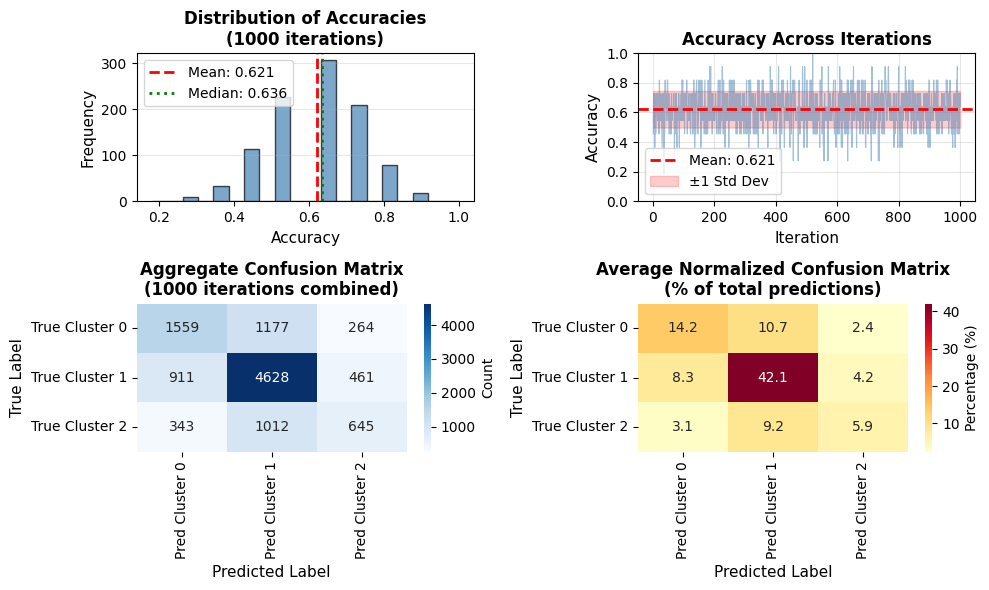

In [76]:
# Monte Carlo Cross-Validation (Repeated Random Subsampling) for LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
X = lda_full_train_ref_habitat.values
y = site_clusters.values

# Monte Carlo CV parameters
n_iterations = 1000  # Number of random train/test splits
test_size = 0.2     # Proportion of data for test set (30%)
random_state = 42

print("="*80)
print("MONTE CARLO CROSS-VALIDATION (Repeated Random Subsampling)")
print("="*80)
print(f"Total samples: {len(y)}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of iterations: {n_iterations}")
print(f"Test size per iteration: {test_size*100:.0f}% (~{int(len(y)*test_size)} samples)")
print(f"Train size per iteration: {(1-test_size)*100:.0f}% (~{int(len(y)*(1-test_size))} samples)")

# Verify cluster proportions will be maintained
cluster_counts = pd.Series(y).value_counts().sort_index()
print("\nCluster sizes:")
for cluster, count in cluster_counts.items():
    test_samples = int(count * test_size)
    print(f"  Cluster {int(cluster)}: {count} total → ~{test_samples} in test set per iteration")

# Initialize Stratified Shuffle Split (maintains class proportions)
sss = StratifiedShuffleSplit(n_splits=n_iterations, test_size=test_size, random_state=random_state)

# Storage for results
iteration_accuracies = []
iteration_predictions = []
iteration_true_labels = []
iteration_confusion_matrices = []
iteration_classification_reports = []

# Track how many times each sample is tested
sample_test_counts = np.zeros(len(y), dtype=int)
sample_correct_predictions = np.zeros(len(y), dtype=int)

cluster_names = [f"Cluster {int(i)}" for i in sorted(np.unique(y))]

print("\n" + "="*80)
print("Running Monte Carlo Cross-Validation...")
print("="*80)

# Perform Monte Carlo Cross-Validation
for iter_idx, (train_idx, test_idx) in enumerate(sss.split(X, y), 1):
    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train LDA on training set
    lda_mc = LinearDiscriminantAnalysis()
    lda_mc.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = lda_mc.predict(X_test)
    
    # Calculate iteration accuracy
    iter_accuracy = accuracy_score(y_test, y_pred)
    iteration_accuracies.append(iter_accuracy)
    
    # Store predictions and true labels
    iteration_predictions.extend(y_pred)
    iteration_true_labels.extend(y_test)
    
    # Track sample-level statistics
    sample_test_counts[test_idx] += 1
    correct_mask = (y_pred == y_test)
    sample_correct_predictions[test_idx] += correct_mask.astype(int)
    
    # Confusion matrix for this iteration
    iter_cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y)))
    iteration_confusion_matrices.append(iter_cm)
    
    # Classification report for this iteration
    iter_report = classification_report(y_test, y_pred, 
                                       target_names=cluster_names,
                                       output_dict=True,
                                       zero_division=0)
    iteration_classification_reports.append(iter_report)
    
    # Print progress every 20 iterations
    if iter_idx % 20 == 0 or iter_idx == 1:
        test_cluster_dist = pd.Series(y_test).value_counts().sort_index().to_dict()
        print(f"Iteration {iter_idx:3d}/{n_iterations}: Accuracy = {iter_accuracy:.4f}, "
              f"Test clusters: {test_cluster_dist}")

# Calculate overall statistics
mean_accuracy = np.mean(iteration_accuracies)
std_accuracy = np.std(iteration_accuracies)
median_accuracy = np.median(iteration_accuracies)
min_accuracy = np.min(iteration_accuracies)
max_accuracy = np.max(iteration_accuracies)

print("\n" + "="*80)
print("MONTE CARLO CV RESULTS")
print("="*80)
print(f"Mean Accuracy: {mean_accuracy:.4f} ({mean_accuracy*100:.2f}%)")
print(f"Std Dev: {std_accuracy:.4f}")
print(f"Median Accuracy: {median_accuracy:.4f} ({median_accuracy*100:.2f}%)")
print(f"Min Accuracy: {min_accuracy:.4f} ({min_accuracy*100:.2f}%)")
print(f"Max Accuracy: {max_accuracy:.4f} ({max_accuracy*100:.2f}%)")
print(f"95% Confidence Interval: [{mean_accuracy - 1.96*std_accuracy:.4f}, {mean_accuracy + 1.96*std_accuracy:.4f}]")

# Per-sample statistics
print("\n" + "="*80)
print("PER-SAMPLE STATISTICS")
print("="*80)
print(f"Average times each sample was tested: {sample_test_counts.mean():.1f}")
print(f"Min/Max times tested: {sample_test_counts.min()}/{sample_test_counts.max()}")

# Calculate per-sample accuracy (for samples that were tested)
sample_accuracies = np.zeros(len(y))
tested_mask = sample_test_counts > 0
sample_accuracies[tested_mask] = sample_correct_predictions[tested_mask] / sample_test_counts[tested_mask]

print(f"Samples never tested: {(~tested_mask).sum()}")
print(f"Samples tested at least once: {tested_mask.sum()}")
print(f"Mean per-sample accuracy: {sample_accuracies[tested_mask].mean():.4f}")

# Overall confusion matrix (aggregated across all iterations)
print("\n" + "="*80)
print("AGGREGATE CONFUSION MATRIX (All Iterations Combined)")
print("="*80)
overall_cm = confusion_matrix(iteration_true_labels, iteration_predictions, 
                              labels=sorted(np.unique(y)))
overall_cm_df = pd.DataFrame(
    overall_cm,
    index=[f"True {name}" for name in cluster_names],
    columns=[f"Pred {name}" for name in cluster_names]
)
print(overall_cm_df)

# Overall classification report
print("\n" + "="*80)
print("AGGREGATE CLASSIFICATION REPORT (All Iterations Combined)")
print("="*80)
print(classification_report(iteration_true_labels, iteration_predictions, 
                           target_names=cluster_names))

# Average metrics across iterations
print("\n" + "="*80)
print("AVERAGE METRICS ACROSS ITERATIONS")
print("="*80)
avg_metrics = {cluster: {'precision': [], 'recall': [], 'f1-score': []} 
               for cluster in cluster_names}
avg_metrics['overall'] = {'precision': [], 'recall': [], 'f1-score': []}

for report in iteration_classification_reports:
    for cluster in cluster_names:
        if cluster in report:
            avg_metrics[cluster]['precision'].append(report[cluster]['precision'])
            avg_metrics[cluster]['recall'].append(report[cluster]['recall'])
            avg_metrics[cluster]['f1-score'].append(report[cluster]['f1-score'])
    
    # Weighted average
    if 'weighted avg' in report:
        avg_metrics['overall']['precision'].append(report['weighted avg']['precision'])
        avg_metrics['overall']['recall'].append(report['weighted avg']['recall'])
        avg_metrics['overall']['f1-score'].append(report['weighted avg']['f1-score'])

print(f"{'Class':<15} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")
print("-" * 80)
for cluster in cluster_names:
    if avg_metrics[cluster]['precision']:
        prec_mean = np.mean(avg_metrics[cluster]['precision'])
        prec_std = np.std(avg_metrics[cluster]['precision'])
        rec_mean = np.mean(avg_metrics[cluster]['recall'])
        rec_std = np.std(avg_metrics[cluster]['recall'])
        f1_mean = np.mean(avg_metrics[cluster]['f1-score'])
        f1_std = np.std(avg_metrics[cluster]['f1-score'])
        print(f"{cluster:<15} {prec_mean:.3f}±{prec_std:.3f}  {rec_mean:.3f}±{rec_std:.3f}  {f1_mean:.3f}±{f1_std:.3f}")

print("-" * 80)
if avg_metrics['overall']['precision']:
    prec_mean = np.mean(avg_metrics['overall']['precision'])
    prec_std = np.std(avg_metrics['overall']['precision'])
    rec_mean = np.mean(avg_metrics['overall']['recall'])
    rec_std = np.std(avg_metrics['overall']['recall'])
    f1_mean = np.mean(avg_metrics['overall']['f1-score'])
    f1_std = np.std(avg_metrics['overall']['f1-score'])
    print(f"{'Weighted Avg':<15} {prec_mean:.3f}±{prec_std:.3f}  {rec_mean:.3f}±{rec_std:.3f}  {f1_mean:.3f}±{f1_std:.3f}")

# Summary
print("\n" + "="*80)
print("MONTE CARLO CV SUMMARY")
print("="*80)
print(f"✓ Performed {n_iterations} random train/test splits")
print(f"✓ Each split maintained stratification (cluster proportions)")
print(f"✓ Each iteration used {test_size*100:.0f}% for testing, {(1-test_size)*100:.0f}% for training")
print(f"✓ Total predictions made: {len(iteration_predictions)}")
print(f"\nKey Finding:")
if mean_accuracy >= 0.6:
    print(f"  → Model shows good generalization (mean accuracy: {mean_accuracy:.1%})")
elif mean_accuracy >= 0.5:
    print(f"  → Model shows moderate generalization (mean accuracy: {mean_accuracy:.1%})")
else:
    print(f"  → Model struggles with generalization (mean accuracy: {mean_accuracy:.1%})")

if std_accuracy < 0.05:
    print(f"  → Low variance across iterations (std: {std_accuracy:.3f}) - stable performance")
elif std_accuracy < 0.10:
    print(f"  → Moderate variance across iterations (std: {std_accuracy:.3f})")
else:
    print(f"  → High variance across iterations (std: {std_accuracy:.3f}) - performance varies with data split")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# 1. Distribution of iteration accuracies
axes[0, 0].hist(iteration_accuracies, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(mean_accuracy, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_accuracy:.3f}')
axes[0, 0].axvline(median_accuracy, color='green', linestyle=':', linewidth=2,
                   label=f'Median: {median_accuracy:.3f}')
axes[0, 0].set_xlabel('Accuracy', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title(f'Distribution of Accuracies\n({n_iterations} iterations)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Accuracy over iterations (to check for trends)
axes[0, 1].plot(range(1, n_iterations + 1), iteration_accuracies, 
                alpha=0.5, color='steelblue', linewidth=0.8)
axes[0, 1].axhline(mean_accuracy, color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {mean_accuracy:.3f}')
axes[0, 1].fill_between(range(1, n_iterations + 1),
                        mean_accuracy - std_accuracy,
                        mean_accuracy + std_accuracy,
                        alpha=0.2, color='red', label=f'±1 Std Dev')
axes[0, 1].set_xlabel('Iteration', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Accuracy Across Iterations', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(alpha=0.3)

# 3. Overall confusion matrix heatmap
sns.heatmap(overall_cm_df, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Count'}, ax=axes[1, 0])
axes[1, 0].set_title(f'Aggregate Confusion Matrix\n({n_iterations} iterations combined)',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontsize=11)
axes[1, 0].set_xlabel('Predicted Label', fontsize=11)

# 4. Average normalized confusion matrix
avg_cm_normalized = np.mean([cm / cm.sum() for cm in iteration_confusion_matrices 
                             if cm.sum() > 0], axis=0)
avg_cm_norm_df = pd.DataFrame(
    avg_cm_normalized * 100,
    index=[f"True {name}" for name in cluster_names],
    columns=[f"Pred {name}" for name in cluster_names]
)
sns.heatmap(avg_cm_norm_df, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'}, ax=axes[1, 1])
axes[1, 1].set_title('Average Normalized Confusion Matrix\n(% of total predictions)',
                     fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('True Label', fontsize=11)
axes[1, 1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

# Store results for comparison
mc_cv_results = {
    'iteration_accuracies': iteration_accuracies,
    'mean_accuracy': mean_accuracy,
    'std_accuracy': std_accuracy,
    'median_accuracy': median_accuracy,
    'min_accuracy': min_accuracy,
    'max_accuracy': max_accuracy,
    'overall_confusion_matrix': overall_cm,
    'iteration_confusion_matrices': iteration_confusion_matrices,
    'iteration_classification_reports': iteration_classification_reports,
    'sample_test_counts': sample_test_counts,
    'sample_accuracies': sample_accuracies,
    'n_iterations': n_iterations,
    'test_size': test_size
}

### Conclusions for Cross-Validation Results

**Monte Carlo Cross-Validation provides a more robust assessment** of LDA performance on chosen clusters with imbalanced sizes.

This cross-validation approach turns out that RDA-supported habitat variables give better performance than the full habitat variables.
This rule (significant habitat variables > full habitat variables) is not revealed in the previous training on full reference sites, which is 
different from the cross-validation results.

## Choose and apply the LDA model to non-reference sites

Based on the Monte Carlo Cross-Validation results, the LDA model with RDA-significant habitat variables is chosen to apply to non-reference sites.
### Predict cluster labels for non-reference sites

Use the trained LDA model with significant habitats to classify non-reference sites into community types based on their habitat characteristics.

In [77]:
# Extract habitat features for non-reference sites
from zci.data_process import get_block

# Extract habitat data for non-reference sites
non_ref_habitat = get_block(non_ref_data, block='environmental', subblock='raw')
print(f"Non-reference habitat data shape: {non_ref_habitat.shape}")
print(f"Number of non-reference sites: {len(non_ref_habitat)}")

# Standardize using the same scaler fitted on reference sites
# This ensures non-reference sites are on the same scale as training data
non_ref_habitat_standardized = habitat_scaler.transform(non_ref_habitat)

# Convert back to DataFrame
non_ref_habitat_standardized = pd.DataFrame(
    non_ref_habitat_standardized,
    columns=non_ref_habitat.columns,
    index=non_ref_habitat.index
)

# Select all habitat features used in LDA training
non_ref_habitat_for_lda = non_ref_habitat_standardized.copy()
print(f"\nStandardized selected habitat data for LDA prediction shape: {non_ref_habitat_for_lda.shape}")

Non-reference habitat data shape: (50, 6)
Number of non-reference sites: 50

Standardized selected habitat data for LDA prediction shape: (50, 6)


In [78]:
# Train a LDA with significant habitats on full training data
full_LDA = LinearDiscriminantAnalysis()
full_LDA.fit(lda_full_train_ref_habitat, site_clusters)
print("\nLDA model trained on full reference data with selected habitats.")


LDA model trained on full reference data with selected habitats.


In [88]:
# Predict cluster labels for non-reference sites using trained LDA model
non_ref_predicted_clusters = full_LDA.predict(non_ref_habitat_for_lda)
non_ref_prediction_proba = full_LDA.predict_proba(non_ref_habitat_for_lda)

# Create results DataFrame
non_ref_predictions_df = pd.DataFrame({
    'Site': non_ref_habitat_for_lda.index,
    'Predicted_Cluster': non_ref_predicted_clusters.astype(int),
    'Waterbody': non_ref_raw_data.loc[non_ref_habitat_for_lda.index, 'Waterbody'].values,
    'SumRel_Pollution': non_ref_raw_data.loc[non_ref_habitat_for_lda.index, 'SumRel'].values
})

# Add prediction probabilities for each cluster
unique_clusters = sorted(np.unique(site_clusters))
for i, cluster_id in enumerate(unique_clusters):
    non_ref_predictions_df[f'Prob_Cluster_{int(cluster_id)}'] = non_ref_prediction_proba[:, i]

# Display results
print("="*80)
print("LDA PREDICTIONS FOR NON-REFERENCE SITES")
print("="*80)
print(f"\nTotal non-reference sites classified: {len(non_ref_predictions_df)}")
print(f"\nCluster distribution:")
print(non_ref_predictions_df['Predicted_Cluster'].value_counts().sort_index())

print("\n" + "="*80)
print("PREDICTION RESULTS WITH PROBABILITIES")
print("="*80)
print(non_ref_predictions_df[-6:].to_string(index=False))

LDA PREDICTIONS FOR NON-REFERENCE SITES

Total non-reference sites classified: 50

Cluster distribution:
Predicted_Cluster
0     8
1    37
2     5
Name: count, dtype: int64

PREDICTION RESULTS WITH PROBABILITIES
Site  Predicted_Cluster Waterbody  SumRel_Pollution  Prob_Cluster_0  Prob_Cluster_1  Prob_Cluster_2
 S97                  1        DR          2.117092        0.051283        0.868417        0.080299
 S98                  1        DR          3.186107        0.005386        0.549000        0.445613
 S99                  0        DR          0.990423        0.920246        0.050351        0.029403
UBC1                  2       LSC          2.084428        0.085935        0.262641        0.651423
UCC1                  2       LSC          0.861696        0.085528        0.200539        0.713933
UJC1                  2       LSC          3.458888        0.063926        0.377058        0.559016


In [80]:
# map the predicted clusters back to the test sites in the raw_data in "Complete_Cluster_Labels" column
raw_data.loc[non_ref_predictions_df['Site'], 'Complete_Cluster_Labels'] = non_ref_predictions_df['Predicted_Cluster'].values.copy()

In [81]:
# map the reference cluster labels back to raw_data
raw_data.loc[site_clusters.index, 'Complete_Cluster_Labels'] = site_clusters.values.copy()

In [82]:
# a function to plot the spatial distribution and comparative barplot of the references
import seaborn as sns
from scipy.stats import f_oneway
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# define a function to read the shp files and quickly plot the lake and river maps
def plot_rivers_lakes(ax = None, annotating = False):
    """Plot the Detroit River with adjacent lakes."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
        
    # read the two shape files of the lakes
    lake_stclair = gpd.read_file("../data/maps/lake_stclair/lake_stclair.shp")
    lake_erie = gpd.read_file("../data/maps/lake_erie/lake_erie.shp")
    detroit_river = gpd.read_file("../data/maps/detroit_river_aoc_shapefile/AOC_MI_Detroit_2021.shp")
    stclair_river = gpd.read_file("../data/maps/aoc_mi_stclair_2021/AOC_MI_StClair_2021.shp")
    lake_huron = gpd.read_file("../data/maps/lake_huron/lake_huron.shp")
    
    # plot the Detroit River and the lakes
    lake_stclair.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    lake_erie.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    lake_huron.plot(ax=ax, color='lightblue', edgecolor='none', alpha=0.5)
    detroit_river.plot(ax=ax, color='lightblue', edgecolor='none')
    stclair_river.plot(ax=ax, color='lightblue', edgecolor='none')
    ax.set_title("The Huron-Erie Corridor")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_ylim(42, 43.1)  # Set y-limits to focus on North America
    ax.set_xlim(-83.3, -82.3)  # Set x-limits to focus on North America
    if annotating:
        ax.text(-83.0, 42.2, 'Detroit River', fontsize=8, color = 'gray', style='italic') 
        ax.text(-82.85, 42.9, 'St. Clair River', fontsize=8, color = 'gray', style='italic')
        ax.text(-82.55, 42.05, 'Lake Erie', fontsize=8, color = 'gray', style='italic')
        ax.text(-83.0, 42.5, 'Lake St. Clair', fontsize=8, color = 'gray', style='italic')
        ax.text(-82.6, 43.05, 'Lake Huron', fontsize=8, color = 'gray', style='italic')
    return fig, ax

def plot_feature_analysis(df, feature_name, lat_col='Latitude', lon_col='Longitude', waterbody_col='Waterbody'):
    """
    Plot a specific habitat feature's spatial distribution and statistical analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    feature_name : str
        Name of the feature column to analyze
    lat_col : str
        Name of the latitude column (default: 'Latitude')
    lon_col : str
        Name of the longitude column (default: 'Longitude')
    waterbody_col : str
        Name of the waterbody column (default: 'Waterbody')
    """
    
    # Create a figure with three subplots: left for map, right side split into two
    fig = plt.figure(figsize=(10, 6), dpi=300)

    # Create subplot layout: left panel takes 1/2 width, right panel split into 2 rows
    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)  # Map spans full left side (1/2 width)
    ax2 = plt.subplot2grid((2, 2), (0, 1))  # Upper right: ridge plot comparison
    ax3 = plt.subplot2grid((2, 2), (1, 1))  # Lower right: ANOVA test results

    # Left panel: Spatial distribution map
    plot_rivers_lakes(ax=ax1, annotating=True)
    # Normalize the feature values to create relative sizes
    feature_values = df[feature_name]
    normalized_sizes = ((feature_values - feature_values.min()) / 
                       (feature_values.max() - feature_values.min()) * 100 + 5)
    
    sc = ax1.scatter(df[lon_col], df[lat_col], c=df[feature_name], 
                     s=normalized_sizes, cmap='viridis', alpha=0.7)
    ax1.set_title(f"Spatial Distribution of {feature_name}", fontsize=14, fontweight='bold')
    ax1.grid(linestyle='--', alpha=0.5)

    # Add colorbar for the scatter plot
    cbar = plt.colorbar(sc, ax=ax1, shrink=0.8)
    cbar.set_label(feature_name, fontsize=12)

    # Upper right: Ridge plot-style comparison across waterbodies
    waterbodies = df[waterbody_col].unique()

    # Create blue gradient colors
    n_bodies = len(waterbodies)
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, n_bodies))

    # Set up the ridge plot parameters
    ridge_height = 0.8  # Height of each ridge
    ridge_spacing = 1.0  # Vertical spacing between ridges
    baseline_offset = 0.1  # Small offset from baseline

    # Clear the axis and set up for ridge plot
    ax2.clear()

    # Create ridge plot with proper stacking
    for i, wb in enumerate(waterbodies):
        data_wb = df[df[waterbody_col] == wb][feature_name].dropna()
        if len(data_wb) > 1:
            # Create smooth density curve using Gaussian KDE
            kde = gaussian_kde(data_wb)
            
            # Create x values for smooth curve
            x_min, x_max = data_wb.min(), data_wb.max()
            x_range = x_max - x_min
            x_smooth = np.linspace(x_min - 0.1*x_range, x_max + 0.1*x_range, 200)
            
            # Calculate density values
            density = kde(x_smooth)
            
            # Normalize density to ridge height
            normalized_density = (density / density.max()) * ridge_height
            
            # Calculate y position for this ridge (bottom to top)
            y_baseline = i * ridge_spacing
            y_values = y_baseline + normalized_density + baseline_offset
            
            # Create the filled area
            ax2.fill_between(x_smooth, y_baseline + baseline_offset, y_values, 
                            color=colors[i], alpha=0.8, edgecolor='white', linewidth=0.5)
            
            # Add a subtle baseline for each ridge
            ax2.axhline(y=y_baseline + baseline_offset, color='lightgray', 
                       linestyle='-', linewidth=0.5, alpha=0.7)

    # Set up the y-axis
    ax2.set_ylim(-0.2, len(waterbodies) * ridge_spacing + 0.5)
    ax2.set_yticks([i * ridge_spacing + baseline_offset + ridge_height/2 for i in range(len(waterbodies))])
    ax2.set_yticklabels(waterbodies, fontsize=11)

    # Style the plot
    ax2.set_title(f"Overlapping densities ('ridge plot')", fontsize=10, fontweight='bold')
    ax2.set_xlabel(feature_name, fontsize=11)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    # Lower right: ANOVA test results with bar plot
    waterbody_groups = [df[df[waterbody_col] == wb][feature_name].dropna() 
                       for wb in waterbodies]
    f_stat, p_value = f_oneway(*waterbody_groups)

    # Calculate means and standard errors
    means = [group.mean() for group in waterbody_groups]
    std_errors = [group.std() / np.sqrt(len(group)) for group in waterbody_groups]

    # Create bar plot with error bars using the same blue gradient
    bars = ax3.bar(waterbodies, means, yerr=std_errors, 
                   alpha=0.8, color=colors, capsize=5, 
                   error_kw={'linewidth': 2, 'markeredgewidth': 2})

    # Add value labels on bars
    for i, (bar, mean) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + std_errors[i] + height*0.02,
                 f'{mean:.2f}', ha='center', va='bottom', fontweight='bold')

    ax3.set_title(f"ANOVA Test: Mean {feature_name} by Waterbody\nF={f_stat:.3f}, p={p_value:.4f}", 
                  fontsize=10, fontweight='bold')
    ax3.set_ylabel(f"Mean {feature_name} ± SE", fontsize=11)
    ax3.set_xlabel("Waterbody", fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['left'].set_visible(False)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    plt.show()
    
    return fig, f_stat, p_value

Complete Site Data Summary:
Total sites: 104
Reference sites: 54
Non-reference sites: 50

Cluster distribution:
Cluster
0.0    25
1.0    65
2.0    14
Name: count, dtype: int64

Habitat Features Standardized with Z-Score:
Mean values (should be ~0): var
LOI (%)                              -0.0
MPS (Phi)                            -0.0
Measured Depth (m)                    0.0
Temperature (oC)                      0.0
Water DO Bottom (mg/L)                0.0
Velocity at bottom (m/sec)_Imputed    0.0
dtype: float64
Std values (should be ~1): var
LOI (%)                               1.004843
MPS (Phi)                             1.004843
Measured Depth (m)                    1.004843
Temperature (oC)                      1.004843
Water DO Bottom (mg/L)                1.004843
Velocity at bottom (m/sec)_Imputed    1.004843
dtype: float64

Mean Habitat Features by Cluster:
var        LOI (%)  MPS (Phi)  Measured Depth (m)  Temperature (oC)  \
Cluster 0   -0.370     -0.971               0.

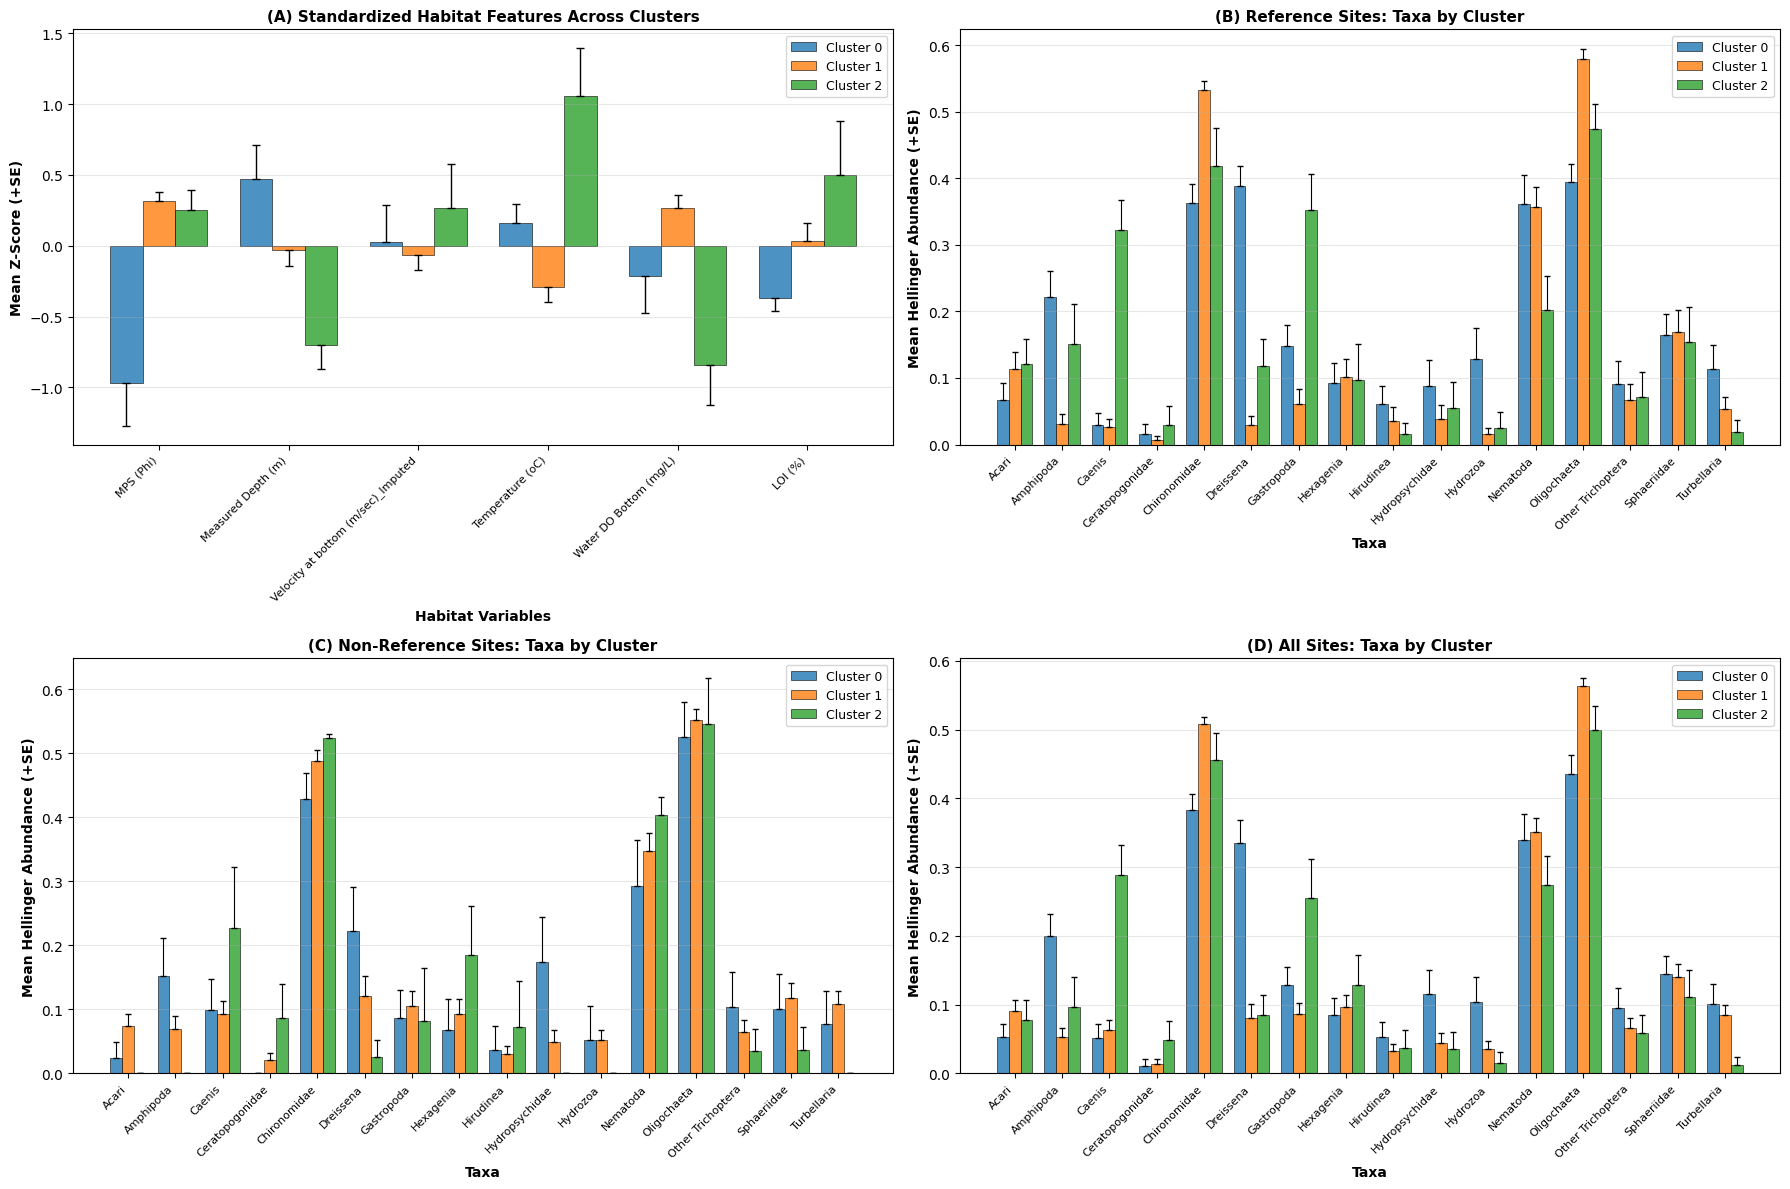


DETAILED SITE BREAKDOWN BY WATERBODY AND CLUSTER
Cluster    0.0  1.0  2.0
Waterbody               
DR           6   10    2
LSC         14   40   12
SCR          5   15    0

REFERENCE SITE CLASSIFICATION ACCURACY CHECK
Reference sites correctly classified: 54/54 (100.00%)


In [83]:
# visualize the difference in habitats, species composition across three clusters and pollution bifurcation
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from scipy import stats

# Create a complete dataset with all necessary information
complete_site_data = pd.DataFrame({
    'Site': raw_data.index,
    'Cluster': raw_data['Complete_Cluster_Labels'],
    'Waterbody': raw_data['Waterbody'],
    'Site_Type': np.where(raw_data['labels'].notna(), 'Reference', 'Non-Reference'),
    'SumRel_Pollution': raw_data['SumRel'],
    'Original_Labels': raw_data['labels']
})

print("Complete Site Data Summary:")
print("="*60)
print(f"Total sites: {len(complete_site_data)}")
print(f"Reference sites: {complete_site_data['Site_Type'].value_counts()['Reference']}")
print(f"Non-reference sites: {complete_site_data['Site_Type'].value_counts()['Non-Reference']}")
print("\nCluster distribution:")
print(complete_site_data['Cluster'].value_counts().sort_index())

# Extract habitat and taxa data for all sites
from zci.data_process import get_block
from sklearn.preprocessing import StandardScaler

all_habitat_raw = get_block(data, block='environmental', subblock='raw')
all_taxa = get_block(data, block='taxa', subblock='raw')

# Standardize habitat features with z-score
habitat_scaler = StandardScaler()
all_habitat_standardized = habitat_scaler.fit_transform(all_habitat_raw)
all_habitat = pd.DataFrame(
    all_habitat_standardized,
    columns=all_habitat_raw.columns,
    index=all_habitat_raw.index
)

print("\n" + "="*60)
print("Habitat Features Standardized with Z-Score:")
print("="*60)
print("Mean values (should be ~0):", all_habitat.mean().round(6))
print("Std values (should be ~1):", all_habitat.std().round(6))

# Apply Hellinger transformation to taxa data
def hellinger_transform(df):
    """Apply Hellinger transformation to taxa data."""
    row_sums = df.sum(axis=1)
    return np.sqrt(df.div(row_sums, axis=0))

all_taxa_hellinger = hellinger_transform(all_taxa)

# Function to calculate mean and std by cluster for a subset of sites
def calculate_data_by_cluster(site_subset, data, return_std=True):
    """Calculate mean and standard error by cluster."""
    # Filter out rows with NaN cluster values
    site_subset_clean = site_subset.dropna(subset=['Cluster'])
    
    if len(site_subset_clean) == 0:
        raise ValueError("No valid cluster labels found in site_subset after removing NaN values")
    
    means = []
    stds = []
    unique_clusters = sorted(site_subset_clean['Cluster'].unique())
    
    for cluster in unique_clusters:
        cluster_sites = site_subset_clean[site_subset_clean['Cluster'] == cluster]['Site']
        cluster_sites_available = [s for s in cluster_sites if s in data.index]
        
        if cluster_sites_available:
            cluster_data = data.loc[cluster_sites_available]
            means.append(cluster_data.mean())
            if return_std:
                # Calculate standard error
                stds.append(cluster_data.sem())  # Standard error of mean
        else:
            means.append(pd.Series(0, index=data.columns))
            if return_std:
                stds.append(pd.Series(0, index=data.columns))
    
    mean_df = pd.DataFrame(means, 
                          index=[f'Cluster {int(i)}' for i in unique_clusters])
    
    if return_std:
        std_df = pd.DataFrame(stds, 
                             index=[f'Cluster {int(i)}' for i in unique_clusters])
        return mean_df, std_df
    return mean_df

# Calculate habitat features by cluster (only for sites with cluster labels)
sites_with_clusters = complete_site_data.dropna(subset=['Cluster'])
habitat_mean, habitat_std = calculate_data_by_cluster(sites_with_clusters, all_habitat)

# Calculate taxa comparison for different site subsets
# Only use sites that have cluster labels assigned
ref_sites = complete_site_data[complete_site_data['Site_Type'] == 'Reference'].dropna(subset=['Cluster'])
nonref_sites = complete_site_data[complete_site_data['Site_Type'] == 'Non-Reference'].dropna(subset=['Cluster'])

# Only calculate if there are sites with cluster labels
if len(ref_sites) > 0:
    taxa_ref_mean, taxa_ref_std = calculate_data_by_cluster(ref_sites, all_taxa_hellinger)
else:
    taxa_ref_mean = pd.DataFrame()
    taxa_ref_std = pd.DataFrame()
    print("Warning: No reference sites with cluster labels found")

if len(nonref_sites) > 0:
    taxa_nonref_mean, taxa_nonref_std = calculate_data_by_cluster(nonref_sites, all_taxa_hellinger)
else:
    taxa_nonref_mean = pd.DataFrame()
    taxa_nonref_std = pd.DataFrame()
    print("Warning: No non-reference sites with cluster labels found")

taxa_all_mean, taxa_all_std = calculate_data_by_cluster(sites_with_clusters, all_taxa_hellinger)

print("\n" + "="*60)
print("Mean Habitat Features by Cluster:")
print("="*60)
print(habitat_mean.round(3))

print("\n" + "="*60)
print("Mean Hellinger-Transformed Taxa Abundance by Cluster:")
print("="*60)
print("\nReference Sites:")
print(taxa_ref_mean.round(3))
print("\nNon-Reference Sites:")
print(taxa_nonref_mean.round(3))
print("\nAll Sites:")
print(taxa_all_mean.round(3))

# Create 4-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Define colors for clusters
cluster_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}  # Blue, Orange, Green

# ==================== AXIS 1: HABITAT FEATURES ACROSS CLUSTERS ====================
ax1 = axes[0, 0]

# Select key habitat variables for visualization
habitat_vars = ['MPS (Phi)', 'Measured Depth (m)', 
                'Velocity at bottom (m/sec)_Imputed', 'Temperature (oC)',
                'Water DO Bottom (mg/L)', 'LOI (%)']

# Filter habitat data to selected variables
habitat_subset_mean = habitat_mean[habitat_vars]
habitat_subset_std = habitat_std[habitat_vars]

# Prepare data for grouped bar plot with error bars
var_names = habitat_subset_mean.columns
n_vars = len(var_names)
n_clusters = len(habitat_subset_mean)
x = np.arange(n_vars)
width = 0.25

# Plot bars for each cluster with conditional error bars
for i, (cluster_name, row) in enumerate(habitat_subset_mean.iterrows()):
    cluster_num = int(cluster_name.split()[-1])
    offset = (i - n_clusters/2 + 0.5) * width
    
    # Get error values
    err_values = habitat_subset_std.loc[cluster_name].values
    
    # Create asymmetric error bars based on sign of values
    lower_errors = np.where(row.values < 0, err_values, 0)
    upper_errors = np.where(row.values >= 0, err_values, 0)
    error_bars = [lower_errors, upper_errors]
    
    ax1.bar(x + offset, row.values, width,
            yerr=error_bars,
            label=cluster_name,
            color=cluster_colors[cluster_num],
            alpha=0.8,
            edgecolor='black',
            linewidth=0.5,
            capsize=3,
            error_kw={'linewidth': 1, 'elinewidth': 1})

ax1.set_xlabel('Habitat Variables', fontsize=10, fontweight='bold')
ax1.set_ylabel('Mean Z-Score (+SE)', fontsize=10, fontweight='bold')
ax1.set_title('(A) Standardized Habitat Features Across Clusters', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(var_names, rotation=45, ha='right', fontsize=8)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ==================== HELPER FUNCTION: PLOT TAXA WITH UPPER ERROR BARS ====================
def plot_taxa_bars_with_error(ax, mean_df, std_df, cluster_colors, title):
    """Plot taxa comparison with upper-only error bars."""
    taxa_names = mean_df.columns
    n_taxa = len(taxa_names)
    n_clusters = len(mean_df)
    x = np.arange(n_taxa)
    width = 0.25
    
    for i, (cluster_name, row) in enumerate(mean_df.iterrows()):
        cluster_num = int(cluster_name.split()[-1])
        offset = (i - n_clusters/2 + 0.5) * width
        
        # Get error values - only upper error bars
        err_values = std_df.loc[cluster_name].values
        # Create asymmetric error: [lower_error, upper_error]
        error_bars = [np.zeros_like(err_values), err_values]
        
        ax.bar(x + offset, row.values, width,
               yerr=error_bars,
               label=cluster_name,
               color=cluster_colors[cluster_num],
               alpha=0.8,
               edgecolor='black',
               linewidth=0.5,
               capsize=2,
               error_kw={'linewidth': 0.8, 'elinewidth': 0.8})
    
    ax.set_xlabel('Taxa', fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean Hellinger Abundance (+SE)', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(taxa_names, rotation=45, ha='right', fontsize=8)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# ==================== AXIS 2: REFERENCE SITES TAXA COMPARISON ====================
ax2 = axes[0, 1]
if not taxa_ref_mean.empty:
    plot_taxa_bars_with_error(ax2, taxa_ref_mean, taxa_ref_std, cluster_colors,
                              '(B) Reference Sites: Taxa by Cluster')
else:
    ax2.text(0.5, 0.5, 'No reference sites\nwith cluster labels', 
             ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('(B) Reference Sites: Taxa by Cluster', fontsize=11, fontweight='bold')

# ==================== AXIS 3: NON-REFERENCE SITES TAXA COMPARISON ====================
ax3 = axes[1, 0]
if not taxa_nonref_mean.empty:
    plot_taxa_bars_with_error(ax3, taxa_nonref_mean, taxa_nonref_std, cluster_colors,
                              '(C) Non-Reference Sites: Taxa by Cluster')
else:
    ax3.text(0.5, 0.5, 'No non-reference sites\nwith cluster labels', 
             ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('(C) Non-Reference Sites: Taxa by Cluster', fontsize=11, fontweight='bold')

# ==================== AXIS 4: ALL SITES TAXA COMPARISON ====================
ax4 = axes[1, 1]
plot_taxa_bars_with_error(ax4, taxa_all_mean, taxa_all_std, cluster_colors,
                          '(D) All Sites: Taxa by Cluster')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*80)
print("DETAILED SITE BREAKDOWN BY WATERBODY AND CLUSTER")
print("="*80)
waterbody_summary = complete_site_data.groupby(['Waterbody', 'Cluster']).size().unstack(fill_value=0)
print(waterbody_summary)

# Reference site accuracy check
print("\n" + "="*80)
print("REFERENCE SITE CLASSIFICATION ACCURACY CHECK")
print("="*80)
ref_sites_with_labels = complete_site_data[complete_site_data['Site_Type'] == 'Reference'].copy()
ref_sites_with_labels = ref_sites_with_labels.dropna(subset=['Cluster', 'Original_Labels'])
ref_sites_with_labels['Original_Cluster'] = raw_data.loc[ref_sites_with_labels['Site'], 'labels']

if len(ref_sites_with_labels) > 0:
    correct_predictions = (ref_sites_with_labels['Cluster'] == ref_sites_with_labels['Original_Cluster']).sum()
    total_ref_sites = len(ref_sites_with_labels)
    accuracy = correct_predictions / total_ref_sites
    print(f"Reference sites correctly classified: {correct_predictions}/{total_ref_sites} ({accuracy:.2%})")
    
    if correct_predictions < total_ref_sites:
        print("\nMisclassified reference sites:")
        misclassified = ref_sites_with_labels[ref_sites_with_labels['Cluster'] != ref_sites_with_labels['Original_Cluster']]
        for _, site in misclassified.iterrows():
            print(f"  {site['Site']}: Original Cluster {int(site['Original_Cluster'])} → Predicted Cluster {int(site['Cluster'])}")
else:
    print("No reference sites with both cluster and original labels found")

## Check the potential spatial patterns behind the habitat features

As the cluster results in 03_notebook, the clusters seem to have shown spatial patterns at three areas:

- Central area of Lake Stain. Clair and part of the delta-influenced area (**Cluster 0**)

- Stain. Clair River and other part of the delta-influenced area (**Cluster 1**)

- Detroit River area (**Cluster 2**)

Therefore, visualizing the predicted cluster labels on these test sites and checking whether they align with the spatial patterns is insightful
to reveal potential spatial autocorrelation in habitat features.

NON-REFERENCE SITES SPATIAL DISTRIBUTION
Total non-reference sites: 50

Predicted cluster distribution:
Cluster
0.0     8
1.0    37
2.0     5
Name: count, dtype: int64

By waterbody:
Cluster    0.0  1.0  2.0
Waterbody               
DR           3    6    0
LSC          2   22    5
SCR          3    9    0


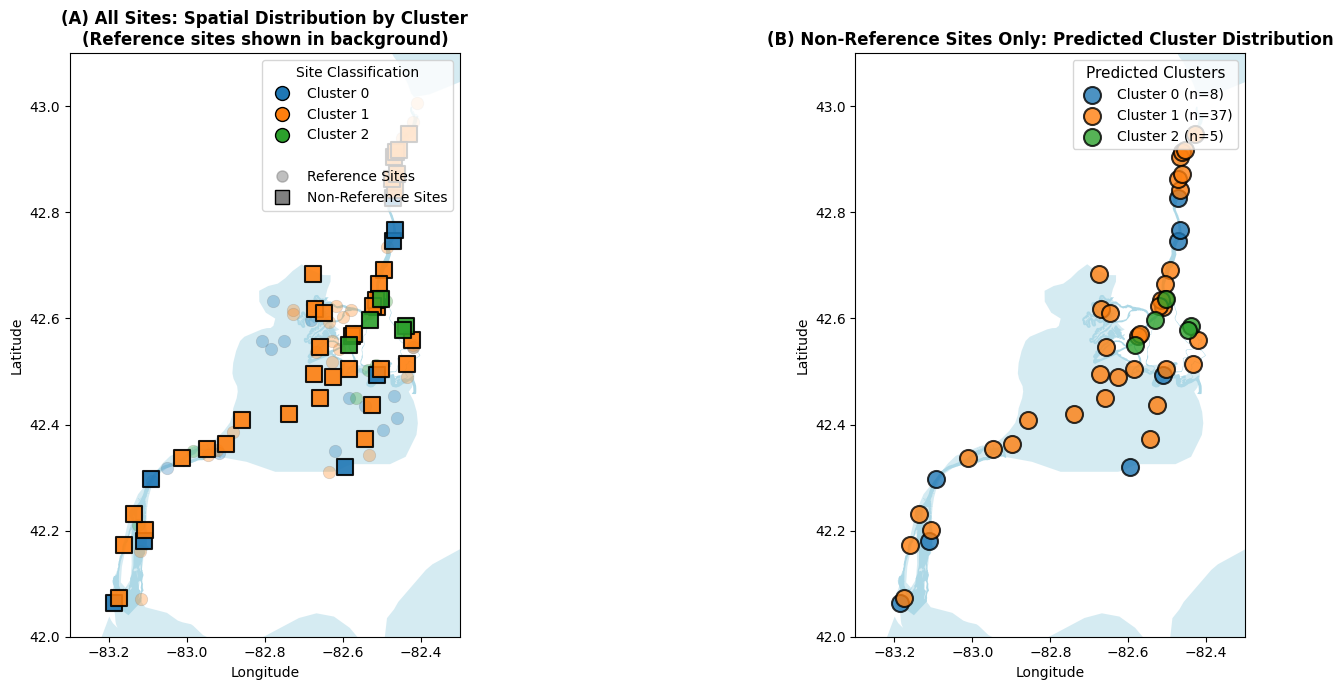


SPATIAL PATTERN ANALYSIS

Cluster 0:
  Number of non-reference sites: 8
  Longitude range: [-83.1863, -82.4667]
  Latitude range: [42.0638, 42.8263]
  Centroid: (-82.7385, 42.4617)
  Waterbodies: {'SCR': 3, 'DR': 3, 'LSC': 2}

Cluster 1:
  Number of non-reference sites: 37
  Longitude range: [-83.1755, -82.4213]
  Latitude range: [42.0731, 42.9476]
  Centroid: (-82.6508, 42.5572)
  Waterbodies: {'LSC': 22, 'SCR': 9, 'DR': 6}

Cluster 2:
  Number of non-reference sites: 5
  Longitude range: [-82.5839, -82.4391]
  Latitude range: [42.5495, 42.6375]
  Centroid: (-82.5007, 42.5896)
  Waterbodies: {'LSC': 5}

ALIGNMENT WITH EXPECTED SPATIAL PATTERNS
Expected patterns from reference site clusters:
  • Cluster 0: Central Lake St. Clair + some delta-influenced areas
  • Cluster 1: St. Clair River + other delta-influenced areas
  • Cluster 2: Detroit River area

Check the map above to see if non-reference sites follow similar spatial patterns,
which would suggest spatial autocorrelation in hab

In [84]:
# Visualize spatial distribution of non-reference sites with predicted cluster labels
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Filter non-reference sites
nonref_site_data = complete_site_data[complete_site_data['Site_Type'] == 'Non-Reference'].copy()

print("="*80)
print("NON-REFERENCE SITES SPATIAL DISTRIBUTION")
print("="*80)
print(f"Total non-reference sites: {len(nonref_site_data)}")
print("\nPredicted cluster distribution:")
print(nonref_site_data['Cluster'].value_counts().sort_index())
print("\nBy waterbody:")
waterbody_cluster = nonref_site_data.groupby(['Waterbody', 'Cluster']).size().unstack(fill_value=0)
print(waterbody_cluster)

# Create spatial visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define colors for clusters
cluster_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}  # Blue, Orange, Green

# ==================== AXIS 1: ALL SITES (Reference + Non-Reference) ====================
ax1 = axes[0]

# Create the base map
plot_rivers_lakes(ax=ax1)

# Plot reference sites (smaller, semi-transparent)
ref_site_data = complete_site_data[complete_site_data['Site_Type'] == 'Reference']
for cluster in sorted(ref_site_data['Cluster'].unique()):
    subset = ref_site_data[ref_site_data['Cluster'] == cluster]
    if len(subset) > 0 and 'Latitude' in raw_data.columns and 'Longitude' in raw_data.columns:
        coords = raw_data.loc[subset['Site'], ['Longitude', 'Latitude']].dropna()
        if len(coords) > 0:
            ax1.scatter(
                coords['Longitude'], coords['Latitude'],
                c=cluster_colors[cluster],
                marker='o',
                s=80,
                alpha=0.3,
                edgecolors='gray',
                linewidth=0.5,
                label=f'Ref Cluster {int(cluster)}' if cluster == 0 else ""
            )

# Plot non-reference sites (larger, prominent)
for cluster in sorted(nonref_site_data['Cluster'].unique()):
    subset = nonref_site_data[nonref_site_data['Cluster'] == cluster]
    if len(subset) > 0 and 'Latitude' in raw_data.columns and 'Longitude' in raw_data.columns:
        coords = raw_data.loc[subset['Site'], ['Longitude', 'Latitude']].dropna()
        if len(coords) > 0:
            ax1.scatter(
                coords['Longitude'], coords['Latitude'],
                c=cluster_colors[cluster],
                marker='s',
                s=120,
                alpha=0.9,
                edgecolors='black',
                linewidth=1.5,
                label=f'Non-Ref Cluster {int(cluster)}'
            )

# Create custom legend
legend_elements = []
# Add cluster colors
for cluster in sorted(complete_site_data['Cluster'].unique()):
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_colors[cluster],
               markersize=10, label=f'Cluster {int(cluster)}', markeredgecolor='black')
    )

legend_elements.append(Line2D([0], [0], color='none', label=''))
# Add site types
legend_elements.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=8, label='Reference Sites', markeredgecolor='gray', alpha=0.5)
)
legend_elements.append(
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markersize=10, label='Non-Reference Sites', markeredgecolor='black')
)

ax1.legend(handles=legend_elements, loc='upper right', title='Site Classification', fontsize=10)
ax1.set_title('(A) All Sites: Spatial Distribution by Cluster\n(Reference sites shown in background)',
              fontsize=12, fontweight='bold')

# ==================== AXIS 2: NON-REFERENCE SITES ONLY ====================
ax2 = axes[1]

# Create the base map
plot_rivers_lakes(ax=ax2)

# Plot only non-reference sites with larger markers
for cluster in sorted(nonref_site_data['Cluster'].unique()):
    subset = nonref_site_data[nonref_site_data['Cluster'] == cluster]
    if len(subset) > 0 and 'Latitude' in raw_data.columns and 'Longitude' in raw_data.columns:
        coords = raw_data.loc[subset['Site'], ['Longitude', 'Latitude']].dropna()
        if len(coords) > 0:
            # Plot sites
            scatter = ax2.scatter(
                coords['Longitude'], coords['Latitude'],
                c=cluster_colors[cluster],
                marker='o',
                s=150,
                alpha=0.8,
                edgecolors='black',
                linewidth=1.5,
                label=f'Cluster {int(cluster)} (n={len(coords)})'
            )
            
            # Optionally add site labels for non-reference sites
            # for site, (lon, lat) in coords.iterrows():
            #     ax2.annotate(site, (lon, lat), fontsize=6, alpha=0.7)

ax2.legend(loc='upper right', title='Predicted Clusters', fontsize=10, title_fontsize=11)
ax2.set_title('(B) Non-Reference Sites Only: Predicted Cluster Distribution',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical summary of spatial patterns
print("\n" + "="*80)
print("SPATIAL PATTERN ANALYSIS")
print("="*80)

# Check if coordinates are available
if 'Latitude' in raw_data.columns and 'Longitude' in raw_data.columns:
    for cluster in sorted(nonref_site_data['Cluster'].unique()):
        cluster_sites = nonref_site_data[nonref_site_data['Cluster'] == cluster]['Site']
        coords = raw_data.loc[cluster_sites, ['Longitude', 'Latitude']].dropna()
        
        if len(coords) > 0:
            print(f"\nCluster {int(cluster)}:")
            print(f"  Number of non-reference sites: {len(coords)}")
            print(f"  Longitude range: [{coords['Longitude'].min():.4f}, {coords['Longitude'].max():.4f}]")
            print(f"  Latitude range: [{coords['Latitude'].min():.4f}, {coords['Latitude'].max():.4f}]")
            print(f"  Centroid: ({coords['Longitude'].mean():.4f}, {coords['Latitude'].mean():.4f})")
            
            # List waterbodies
            waterbodies = nonref_site_data[nonref_site_data['Cluster'] == cluster]['Waterbody'].value_counts()
            print(f"  Waterbodies: {waterbodies.to_dict()}")

# Summary of alignment with expected spatial patterns
print("\n" + "="*80)
print("ALIGNMENT WITH EXPECTED SPATIAL PATTERNS")
print("="*80)
print("Expected patterns from reference site clusters:")
print("  • Cluster 0: Central Lake St. Clair + some delta-influenced areas")
print("  • Cluster 1: St. Clair River + other delta-influenced areas")  
print("  • Cluster 2: Detroit River area")
print("\nCheck the map above to see if non-reference sites follow similar spatial patterns,")
print("which would suggest spatial autocorrelation in habitat features.")

## Output the results with predicted cluster labels for non-reference sites

The RDA aims to explain the habitat-driven commmunity composition for the sites, further explanations with their clusters, spatial patterns, etc.
It also indicates important and **siginificant habitat features** for LDA, which improves the LDA performance in cross-validation.

The LDA aims to generalize the habitat-driven community types(clusters) to test sites (anthropogenically disturbed sites) based on their habitat features.
The LDA axes act differently from RDA axes, but they both derive from habitat features (explicitly or implicitly, constrained).
LDA favors the separation of clusters to make discrete predictions, while RDA favors the explanation of community composition to reveal continuous gradients that drive species distributions.

Overall, the required outputs are the reliable (supported by Monte Carlo CV) predicted cluster labels for non-reference sites.
These predictions joint with the chosen clusters in ref-sites comprise the final habitat-driven community typology for all sites.

These clusters, chosen, predicted and mixed, should and seem to have ecological intergrity in terms of habitat features and species composition.

In [85]:
# merge the predicted clusters of non-reference sites to the multi-subblock data set
data[("cluster_info", "complete", "Complete_Cluster_Labels")] = raw_data['Complete_Cluster_Labels'].copy()
data.head()

block     sample_info                           environmental            \
subblock          raw                                     raw             
var          Latitude Longitude Waterbody  Year       LOI (%) MPS (Phi)   
StationID                                                                 
A10          42.90455 -82.46760       SCR  2004      3.436193  1.734259   
A23          42.56658 -82.57595       LSC  2004      3.226637  1.969984   
A27          42.56007 -82.42132       LSC  2004      2.802642  1.319519   
A28          42.54577 -82.42073       LSC  2004      3.201399  1.398687   
A29          42.51440 -82.43462       LSC  2004      6.180718  1.065748   

block                                                                 \
subblock                                                               
var       Measured Depth (m) Temperature (oC) Water DO Bottom (mg/L)   
StationID                                                              
A10                      1.8            19.17                  10.21   
A23                      3.0            19.10                  10.09   
A27                      1.0            18.40                  10.30   
A28                      0.5            18.90                  12.80   
A29                      0.5            19.30                   9.70   

block      chemical  ...              taxa                              \
subblock        raw  ...               raw                               
var             %OC  ... Other Trichoptera   Sphaeriidae   Turbellaria   
StationID            ...                                                 
A10        3.436193  ...      3.203427e-16  3.203427e-16  3.203427e-16   
A23        3.226637  ...      3.203427e-16  1.022139e+00  5.997595e-01   
A27        2.802642  ...      1.580169e+00  1.317615e+00  9.964067e-01   
A28        3.201399  ...      2.049287e+00  2.863547e+00  3.203427e-16   
A29        6.180718  ...      3.203427e-16  3.203427e-16  3.203427e-16   

block     2008_results                         pollution  ref_sites_clusters  \
subblock   DR_clusters       corridor_clusters     01_04 wards_hellinger_euc   
var         DR_cluster if_RF  corridor_cluster    SumRel              labels   
StationID                                                                      
A10                  0     0                 1  0.036975                 NaN   
A23                  0     0                 1  1.863096                 NaN   
A27                  0     0                 1  0.413007                 NaN   
A28                  0     0                 1 -1.237461                 1.0   
A29                  0     0                 1  0.233305                 NaN   

block                          environmental            cluster_info  
subblock                                 raw                complete  
var       Velocity at bottom (m/sec)_Imputed Complete_Cluster_Labels  
StationID                                                             
A10                                 0.190172                     1.0  
A23                                 0.105506                     1.0  
A27                                 0.009388                     1.0  
A28                                 0.177290                     1.0  
A29                                 0.096495                     1.0  

[5 rows x 62 columns]

In [86]:
# output the merged complete data to a new file
import time
from datetime import datetime
# output the merged complete data to a new file with timestamp
current_time = datetime.now().strftime("%m_%d_%H_%M")
filename = f"../data/processed/04_LDA_Habitat_Separation_Results/04_data_with_complete_cluster_labels_{current_time}.xlsx"
data.to_excel(filename)
print(f"✓ Data exported to: {filename}")

✓ Data exported to: ../data/processed/04_LDA_Habitat_Separation_Results/04_data_with_complete_cluster_labels_01_06_16_00.xlsx
